# [LAB 06] 데이터 시각화 - 3. KDE Plot 

## #01. 준비작업 

### 1. 패키지 가져오기 


In [1]:
from jussam import load_data
from helpers import * 
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 

In [2]:
origin = load_data("iris")
origin.head()

📚 1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

    field         description
--  ------------  -------------
 0  Sepal.Length  꽃받침 길이
 1  Sepal.Width   꽃받침 너비
 2  Petal.Length  꽃잎 길이
 3  Petal.Width   꽃잎 너비
 4  Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


## #02. 일변량 커널 밀도 

### 1. 단일 분포 -> 하나의 변수에 대한 KDE Plot 

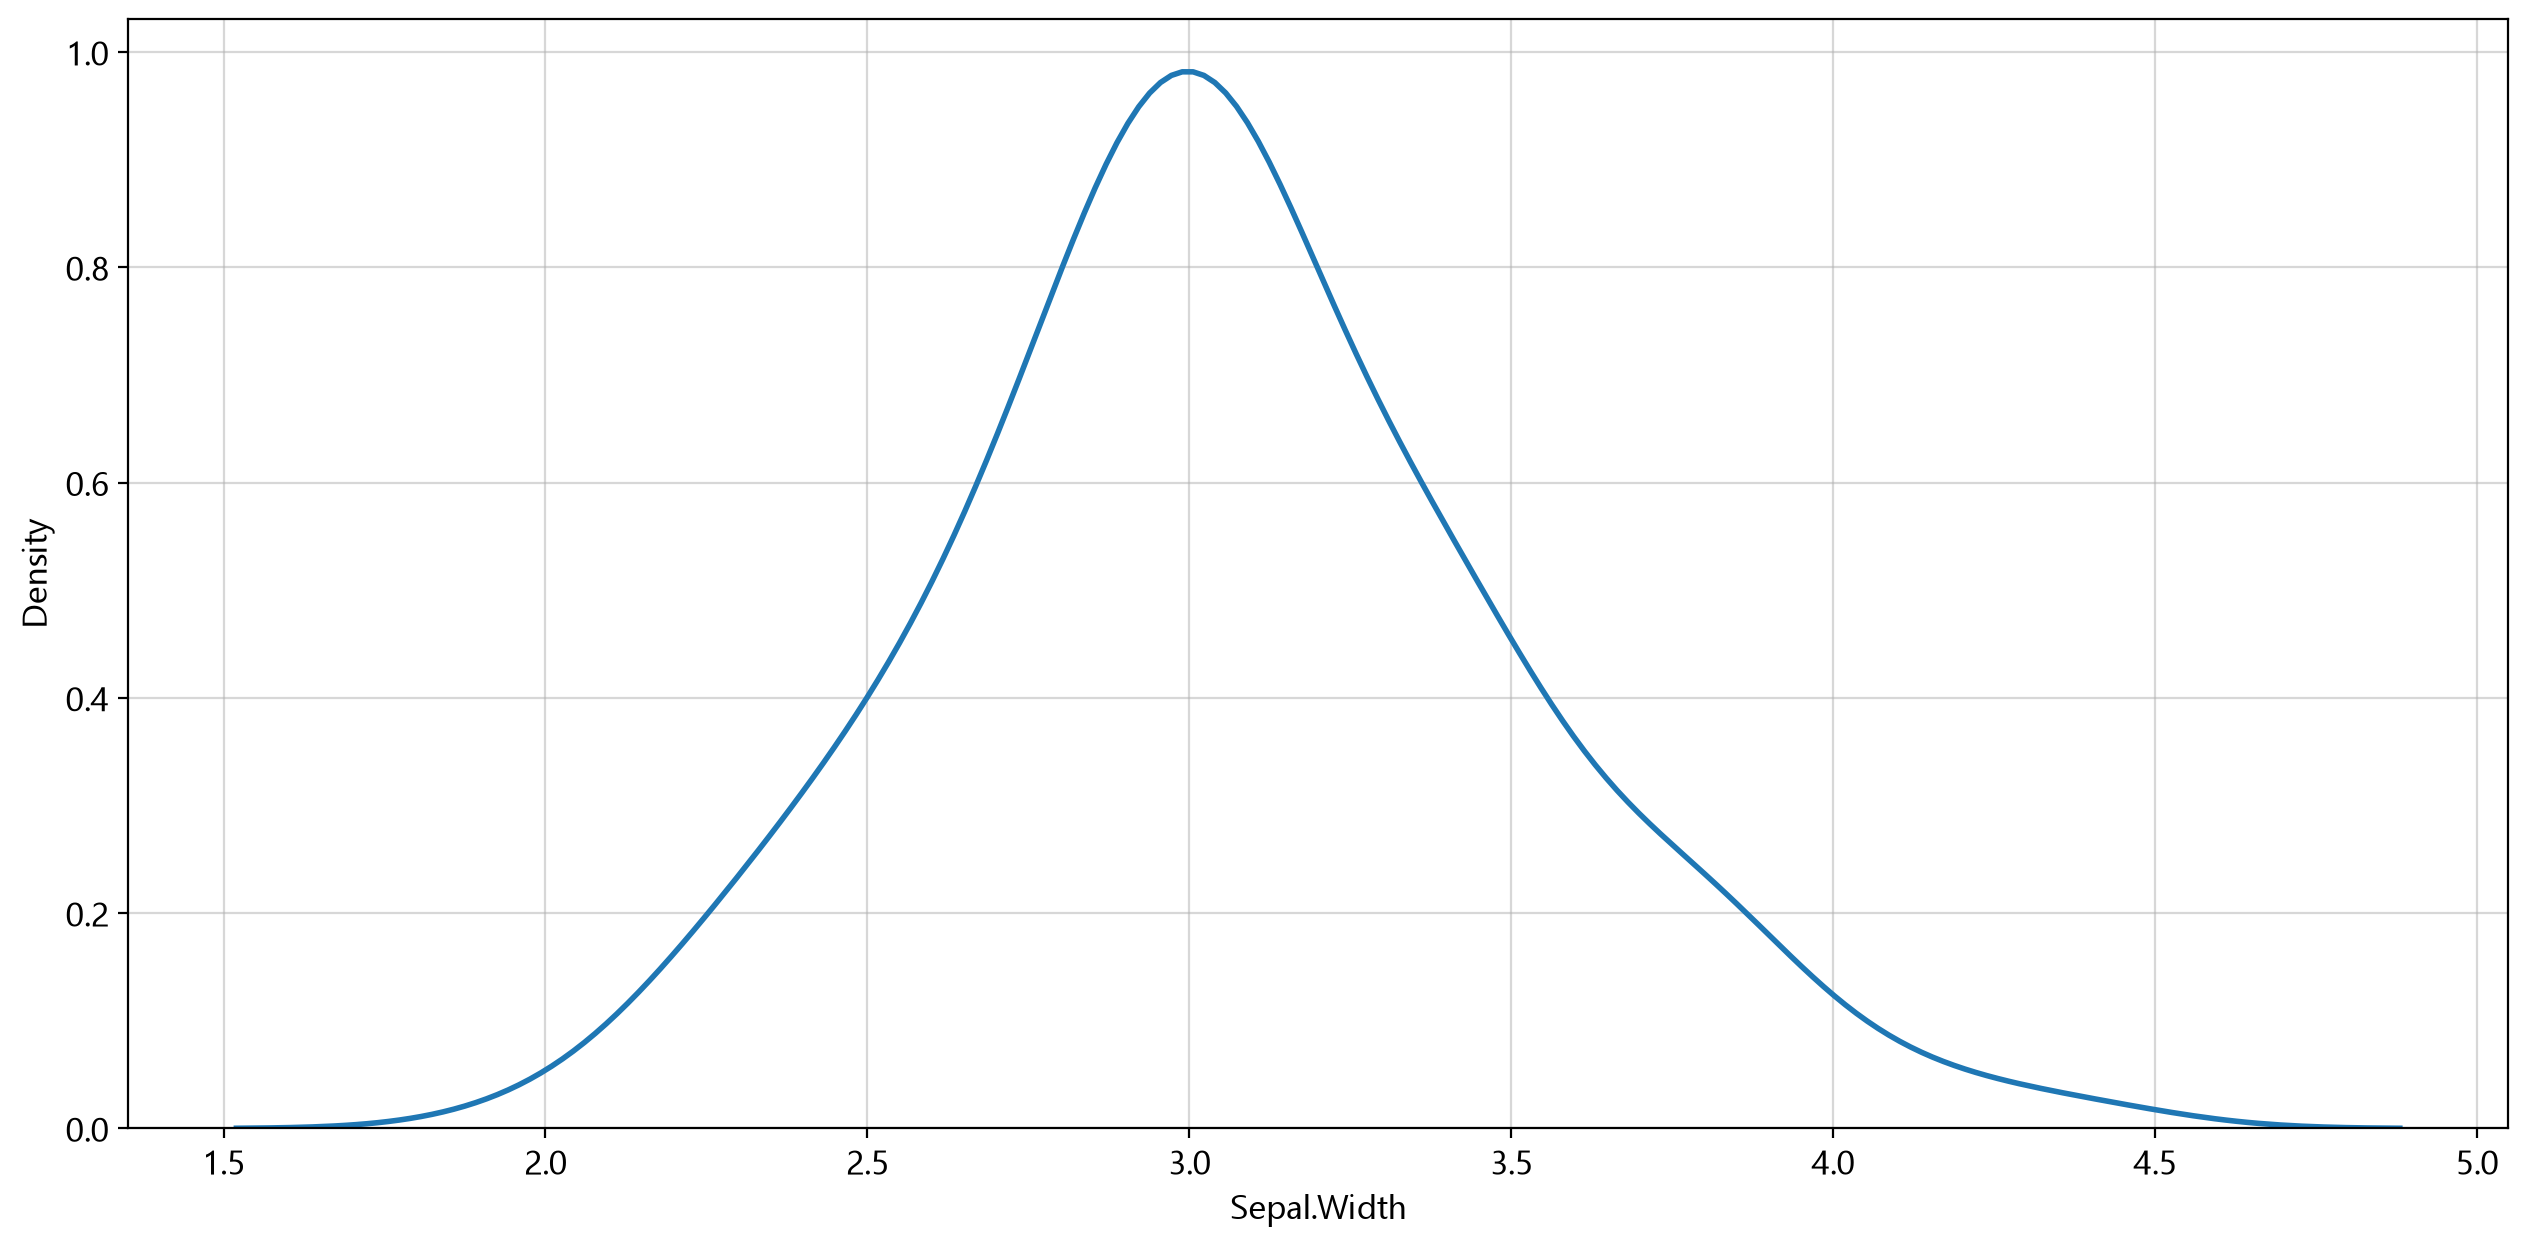

In [3]:
# 그래프 초기화 
fig, ax = my_plot.init()

# 그래프 그리기 ( 아래 패턴 3가지는 모두 결과가 동일함)
# [패턴1] 자동인식 패턴 
# sb.kdeplot(data = origin["Sepal.Width"])
# [패턴2] 개별 데이터 지정 패턴 
# sb.kedplot( x= origin["Sepal.Width"])
# [패턴3] DataFrame 지정 패턴 
sb.kdeplot(data=origin, x="Sepal.Width", linewidth=2)

# 출력 
my_plot.show()

### 2. 다중 분포 

- 데이터 프레임을 data 파라미터에 적용하면서 x나 y파라미터를 지정하지 않으면 
모든 연속형 변수에 대한 커널 밀도 곡선이 표현된다.

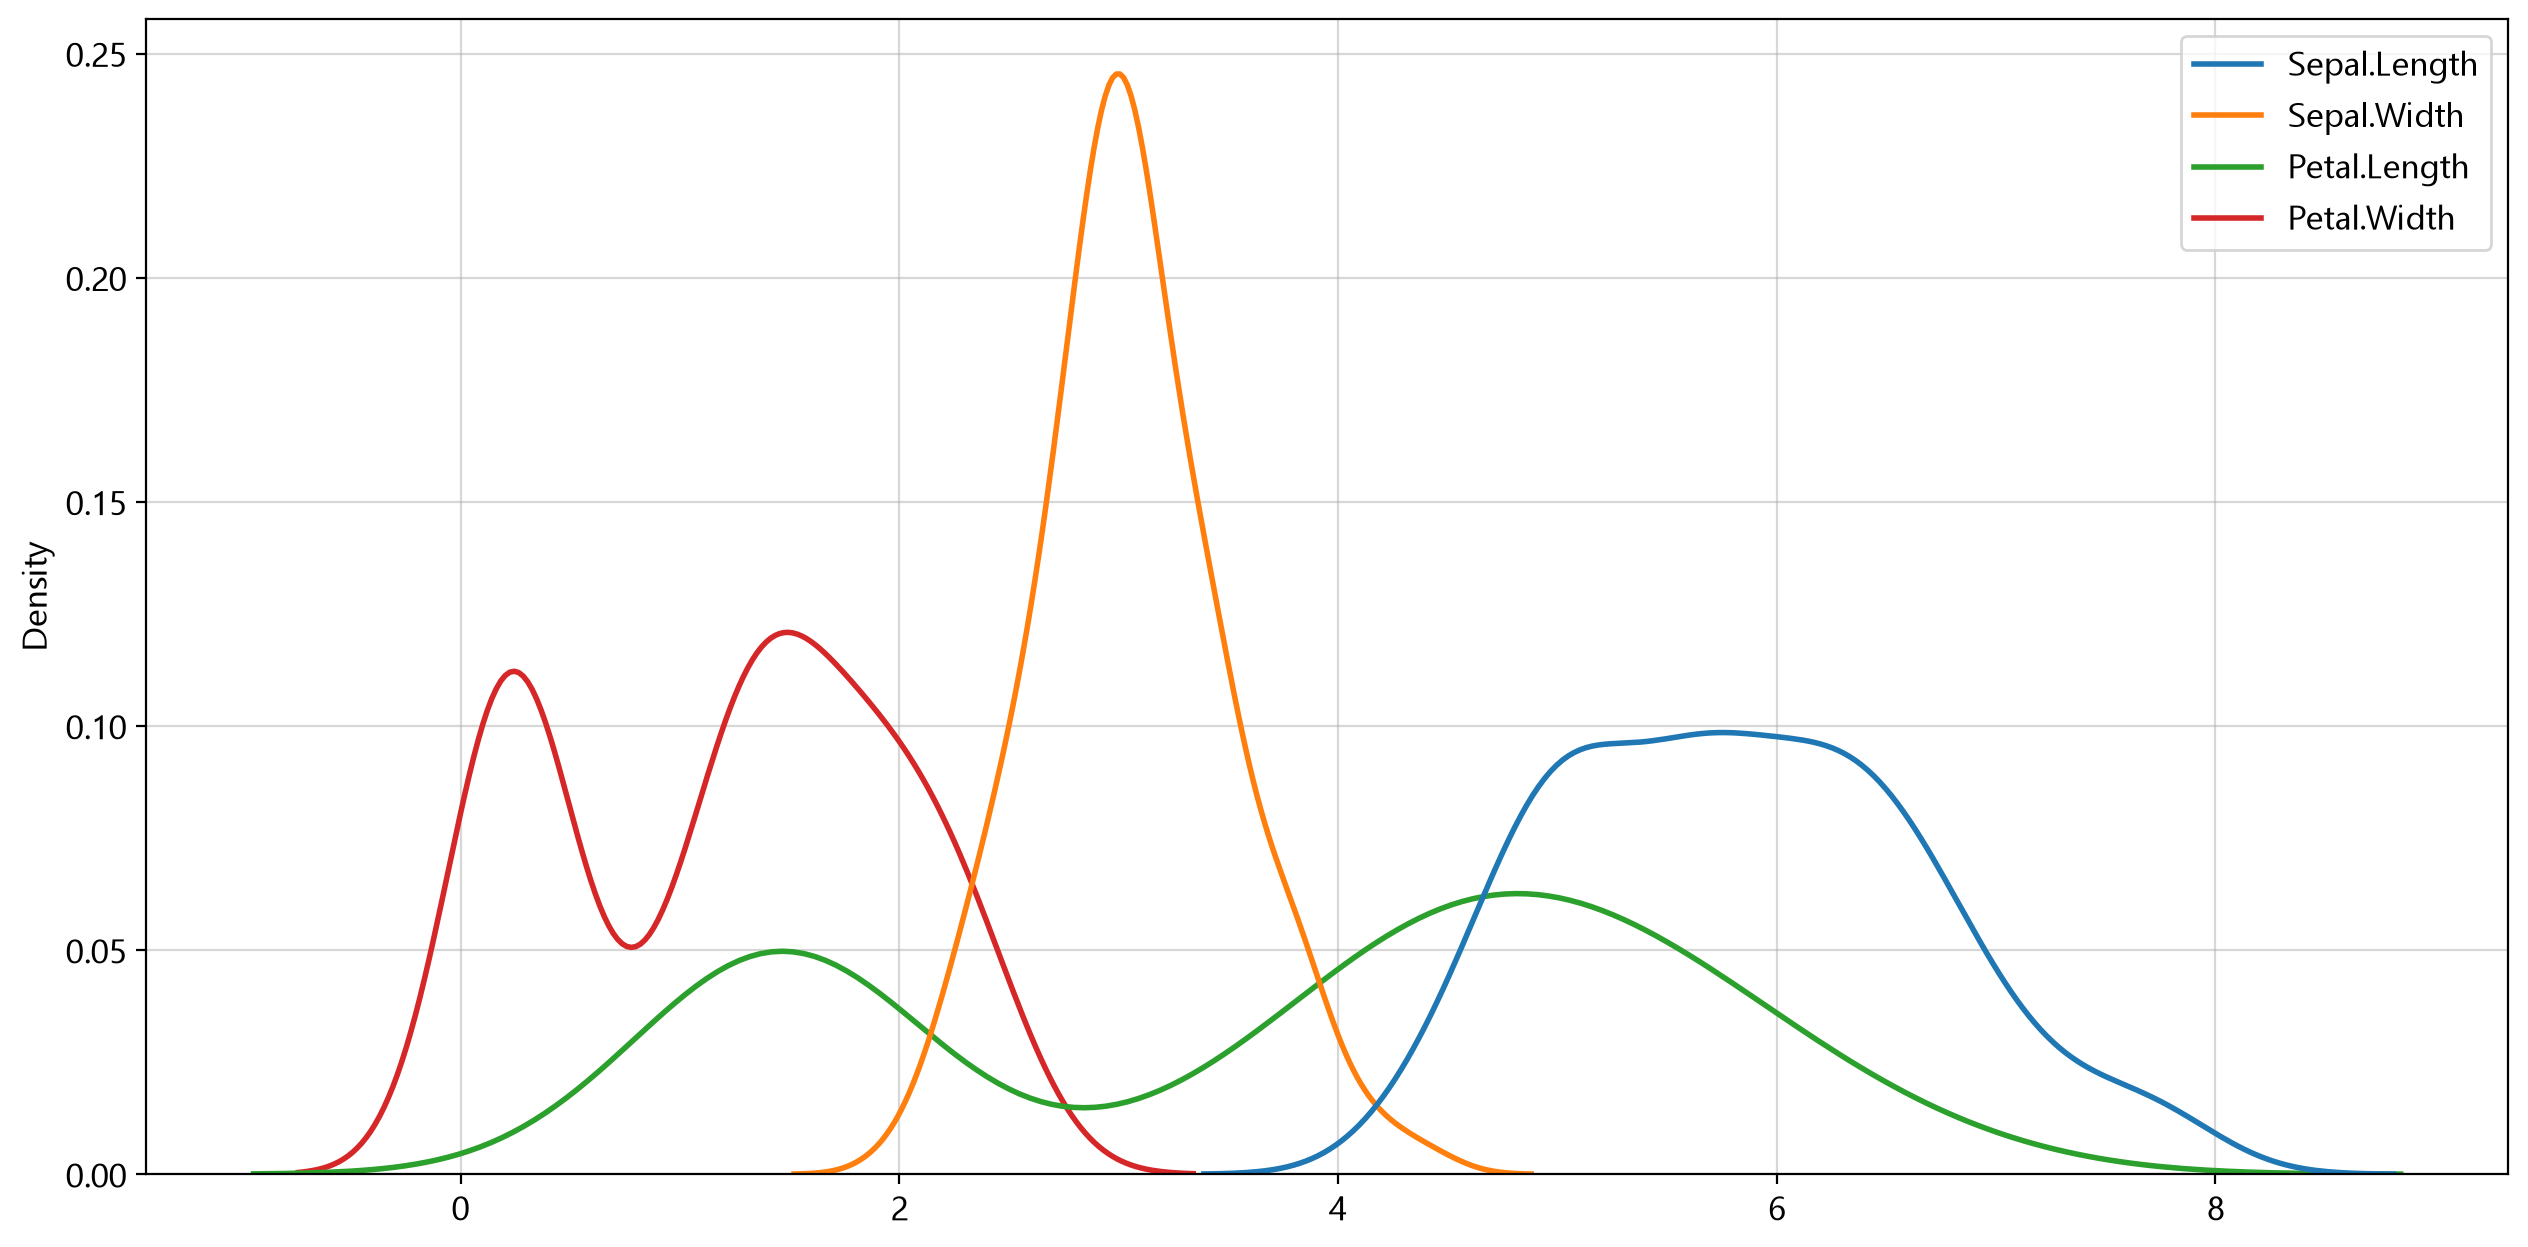

In [4]:
# 그래프 초기화 
fig, ax = my_plot.init()

# 그래프 그리기 - x 대신 y를 설정할 경우 가로로 표시된다. 
sb.kdeplot(data=origin)

# 출력 
my_plot.show()

### 3. 옵션 설정 

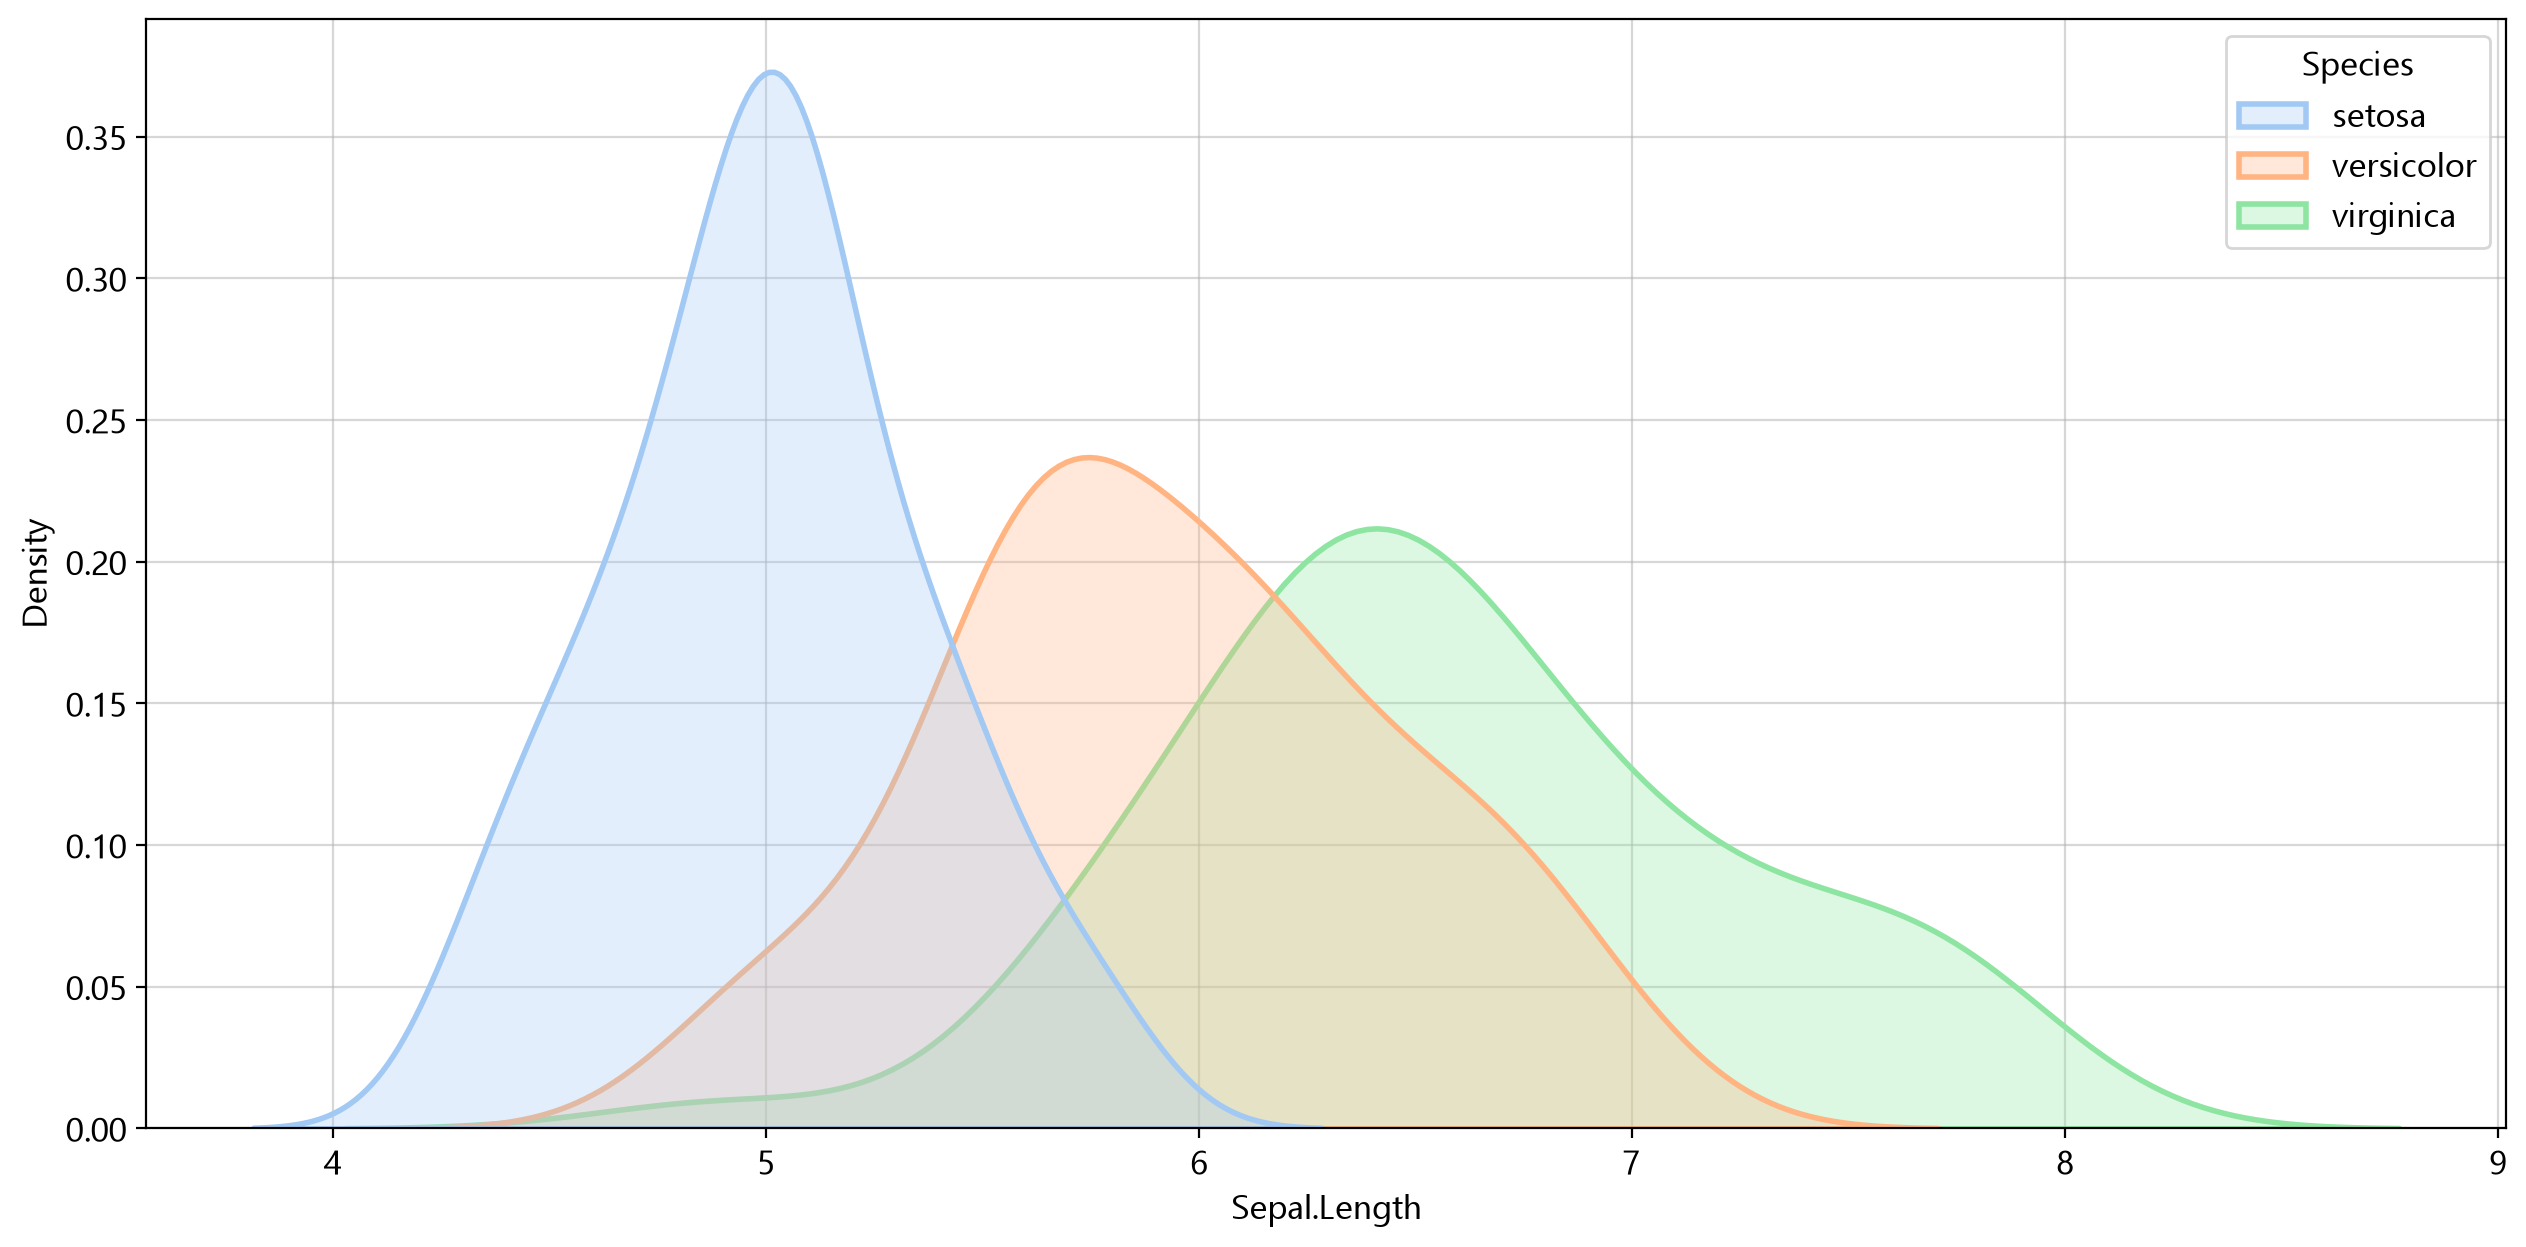

In [5]:
# 그래프 초기화 
fig, ax = my_plot.init()

# 그래프 그리기 
sb.kdeplot(
    data=origin,        # 데이터 연결  
    x="Sepal.Length",   # 분포를 확인할 컬럼 지정 
    hue="Species",      # 범주 지정 
    fill=True,          # 면 색상 채움 
    alpha = 0.3,        # 면 색상의 투명도 
    palette="pastel",   # 색상 팔레트 
    linewidth=2         # 선의 두께
)

# 출력 
my_plot.show()

## #03. 이변량 커널 밀도 

### 1. x에 따른 y분포 

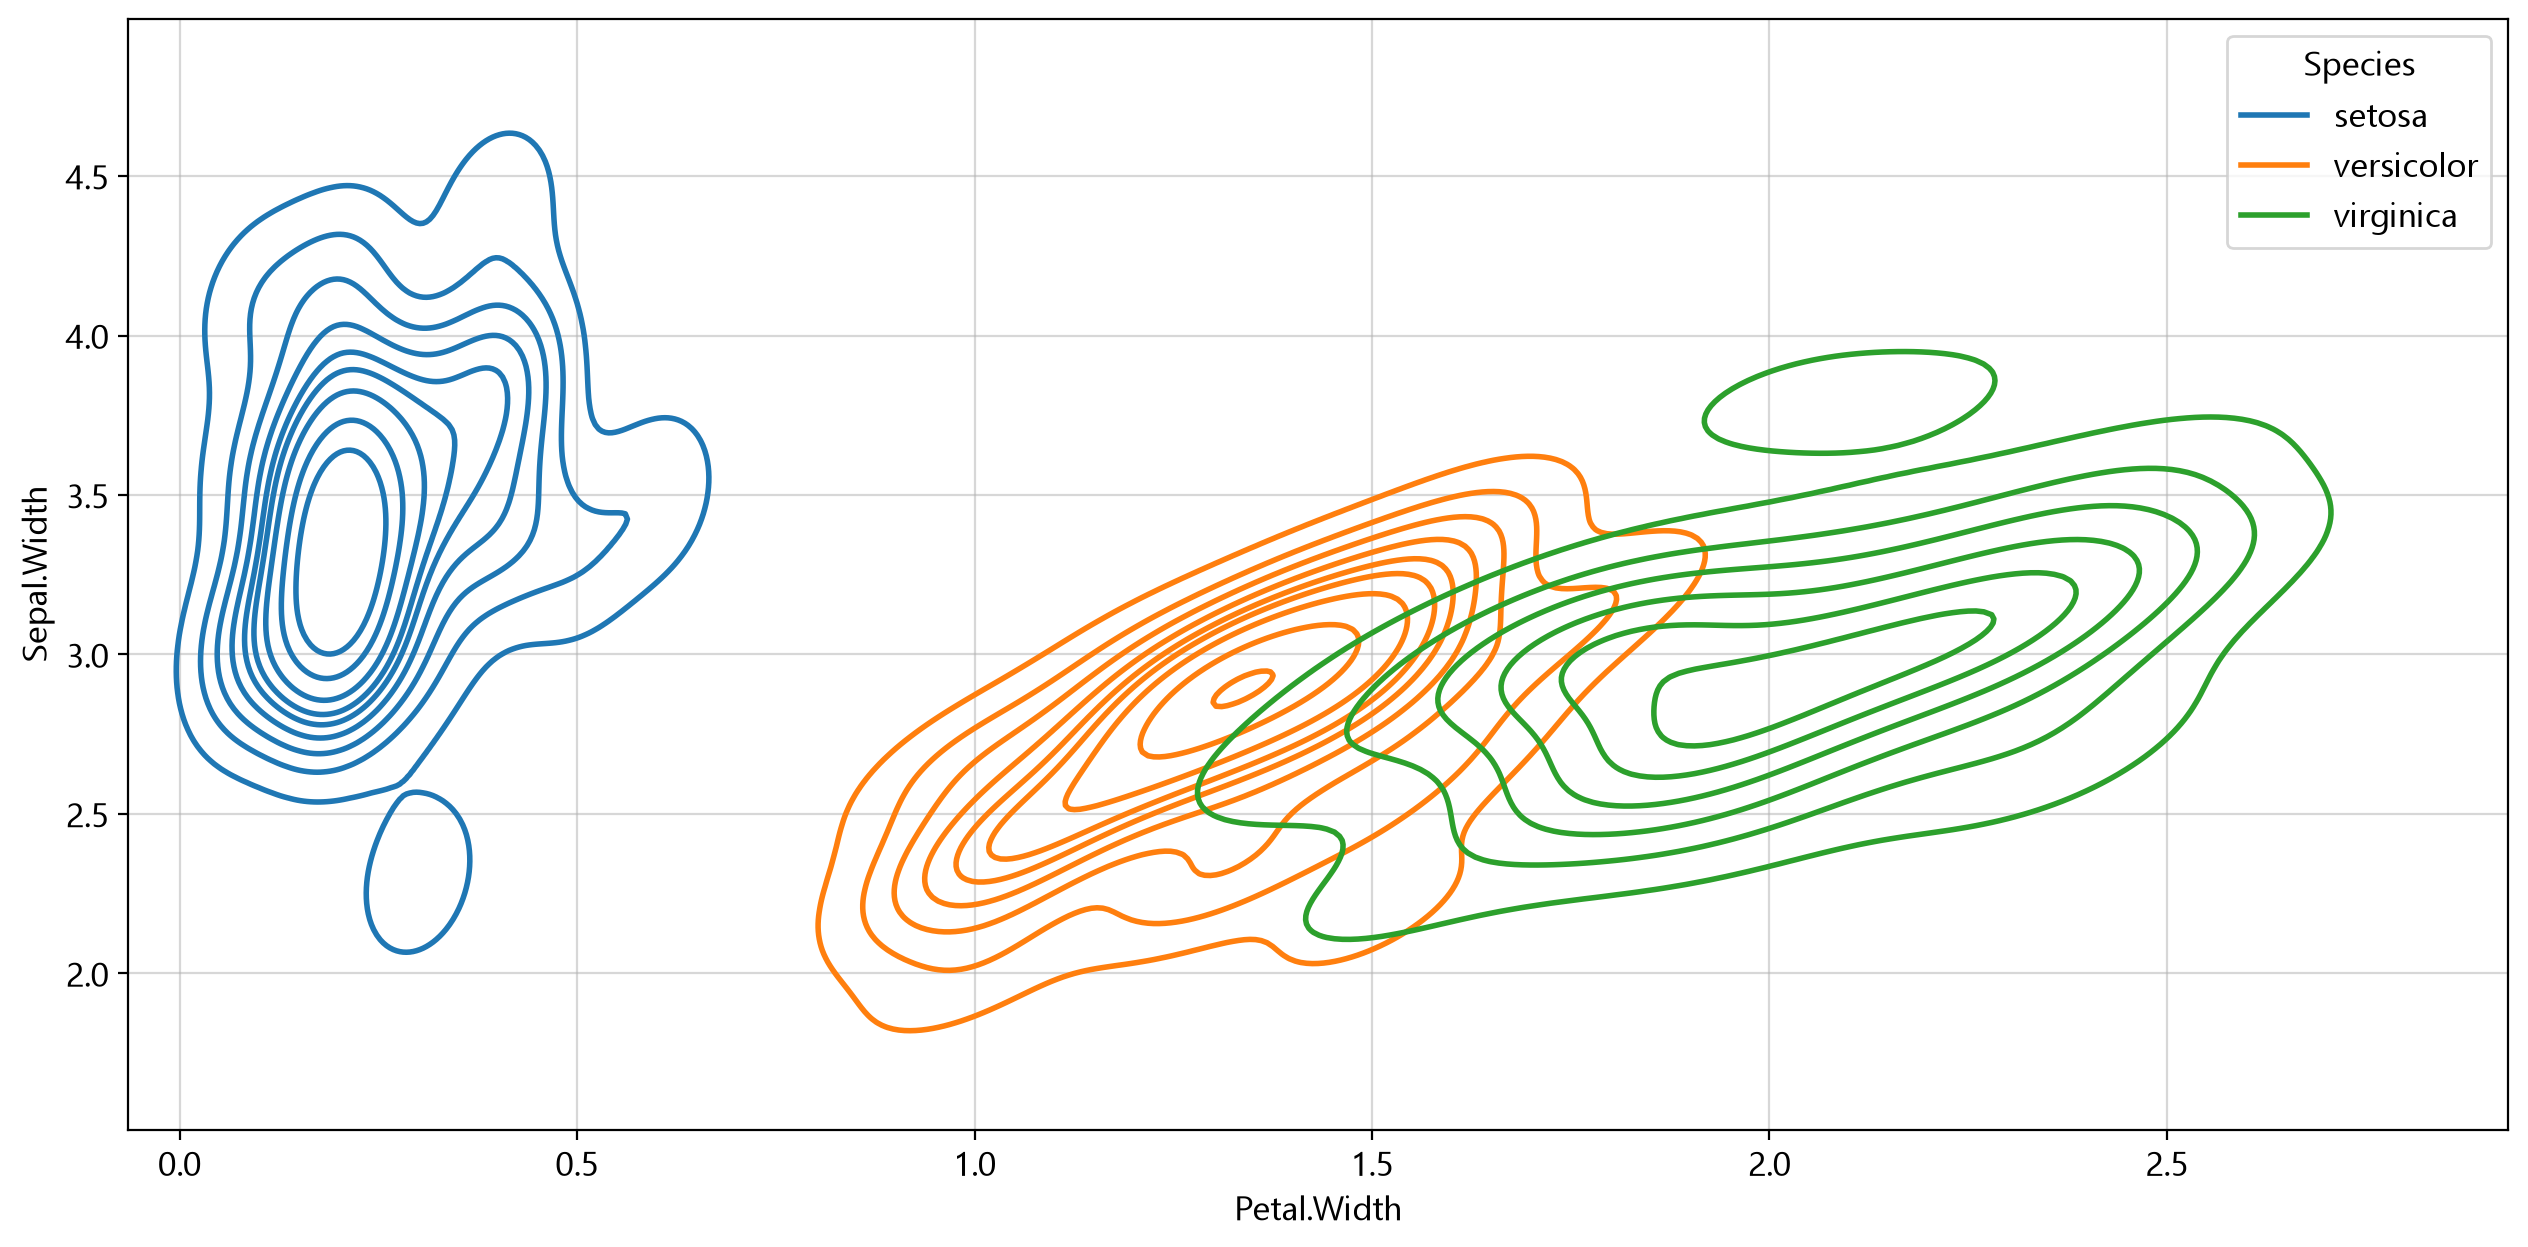

In [6]:
# 그래프 초기화 
fig, ax = my_plot.init()

# 그래프 그리기 
sb.kdeplot(data=origin, x="Petal.Width", 
           y="Sepal.Width", hue="Species")

# 출력 
my_plot.show()

## #04. 커널밀도와 평균값을 함께 표시하기 

### 1. 평균값 구하기 

In [7]:
mean_sepal_width = origin["Sepal.Width"].mean()
print(mean_sepal_width)

3.0573333333333337


### 2. 커널밀도 + 평균값 

- ax.axvline() : x축 지점에 수직인 세로 직선을 그릴 수 있다. 
- ax.text() : 특정 좌표 지점에 텍스트를 표시할 수 있다. 

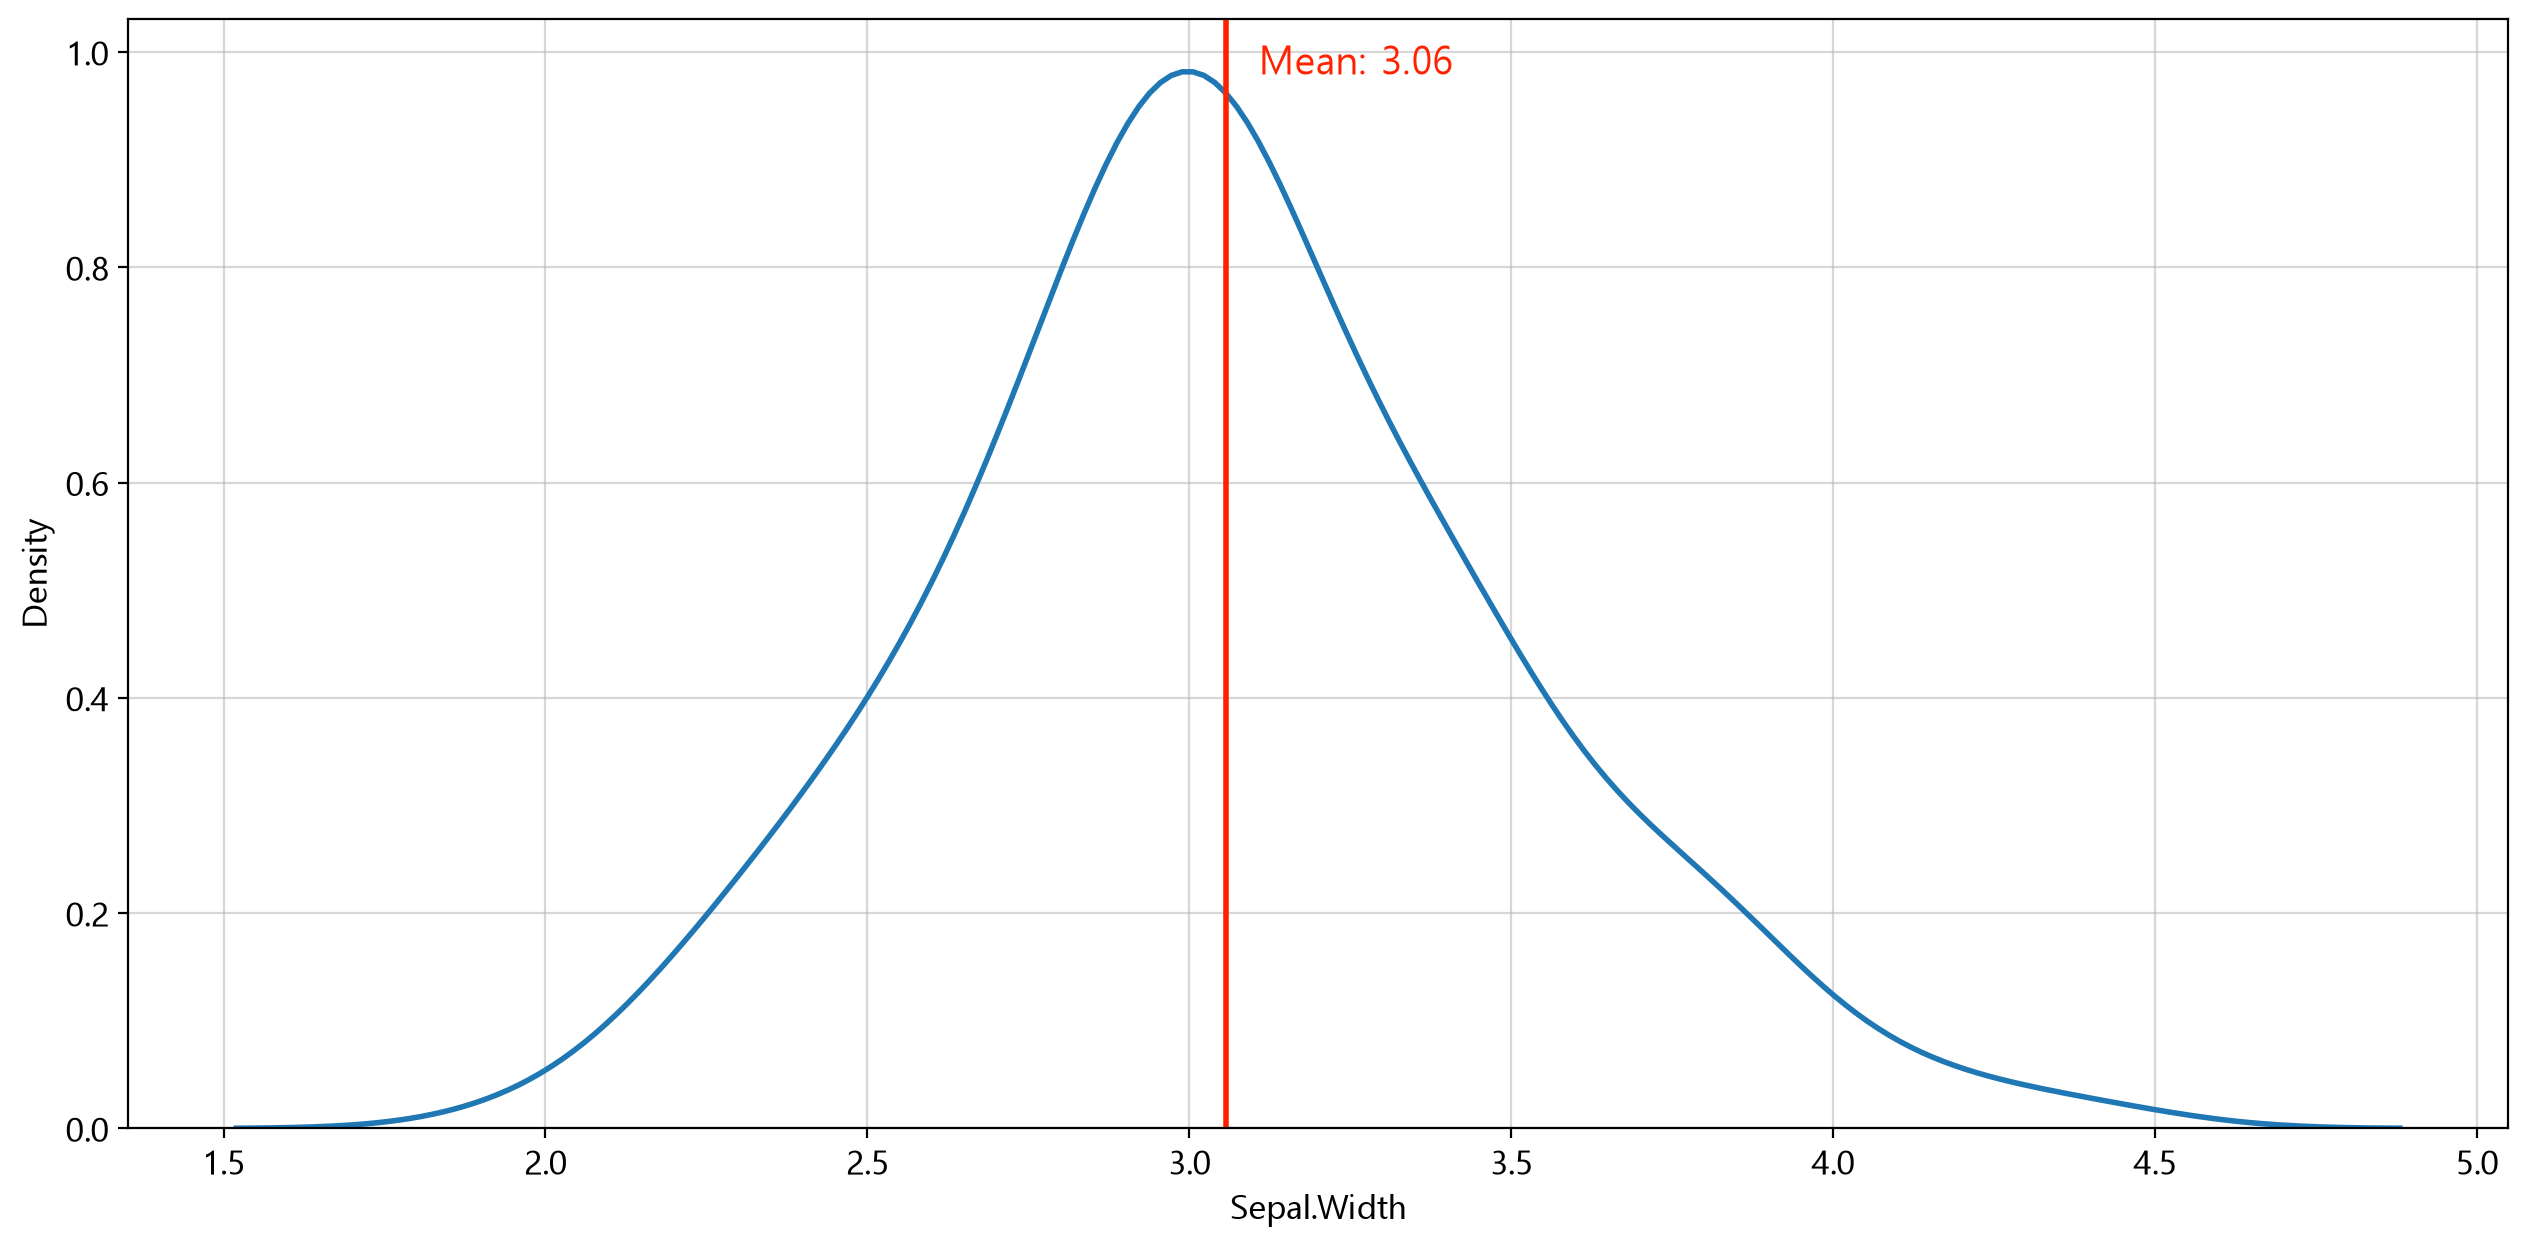

In [8]:
# 그래프 초기화 
fig, ax = my_plot.init()

# 그래프 그리기 
sb.kdeplot(data=origin, x="Sepal.Width")    

# 평균에 대한 수직선 추가 
ax.axvline(x=mean_sepal_width, linestyle='-', color='#ff2200')

# 텍스트 표시하기 
ax.text(x=mean_sepal_width +0.05, y=ax.get_ylim()[1]*0.95, 
        s=f'Mean: {mean_sepal_width:.2f}', color ='#ff2200', fontsize=14)

# 출력 
my_plot.show()

## #05. 모듈화 기능 확인 

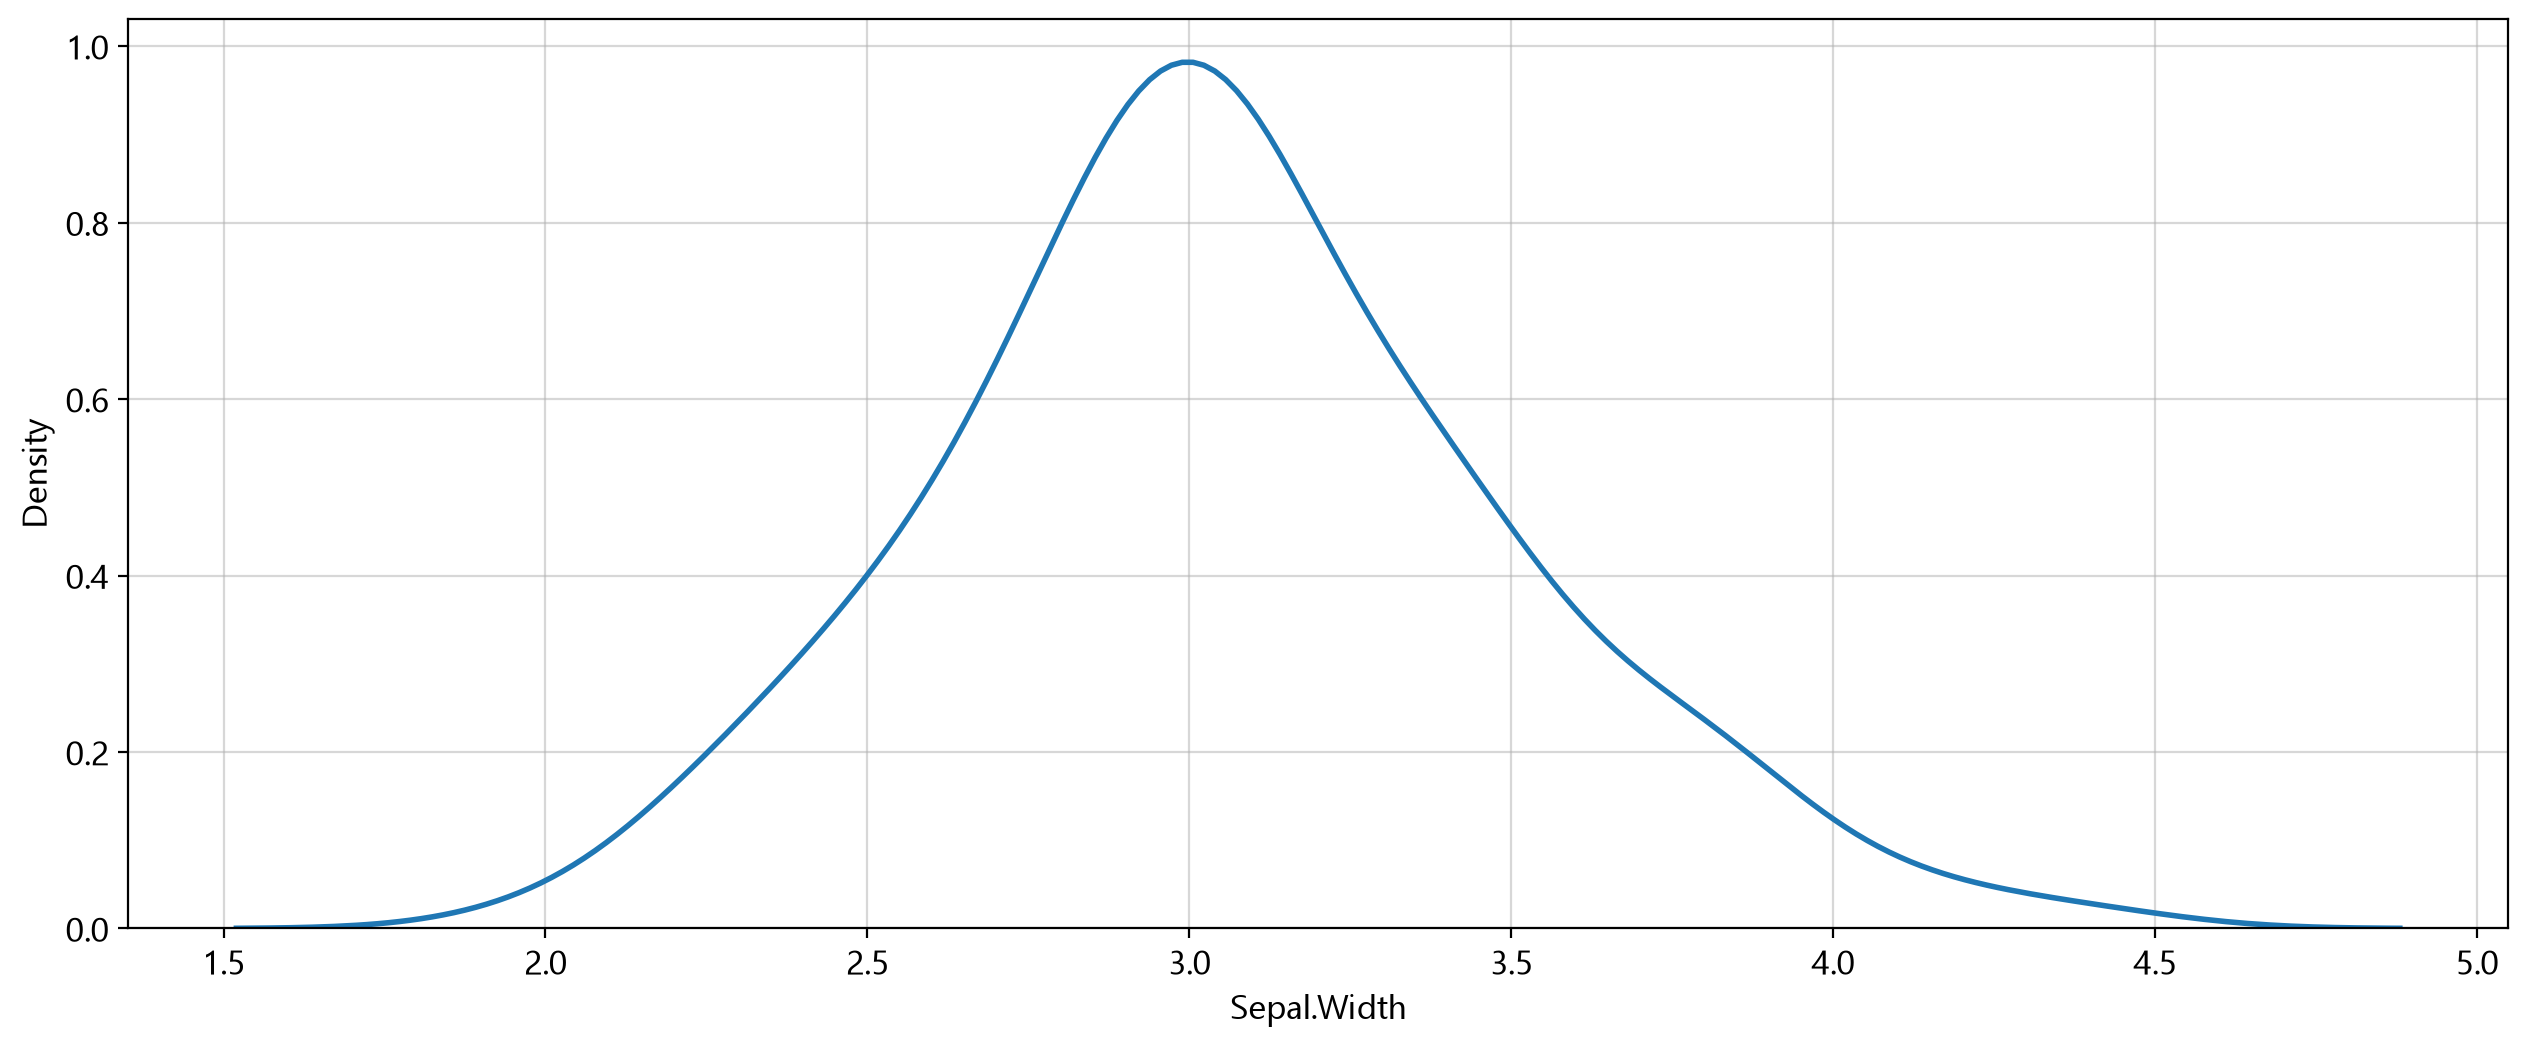

In [9]:
my_plot.kdeplot(data=origin, x="Sepal.Width")

### 2. 제목, 라벨, 평균선 표시 / 색상 채우기 

findfont: Failed to find font weight 500, now using 400.


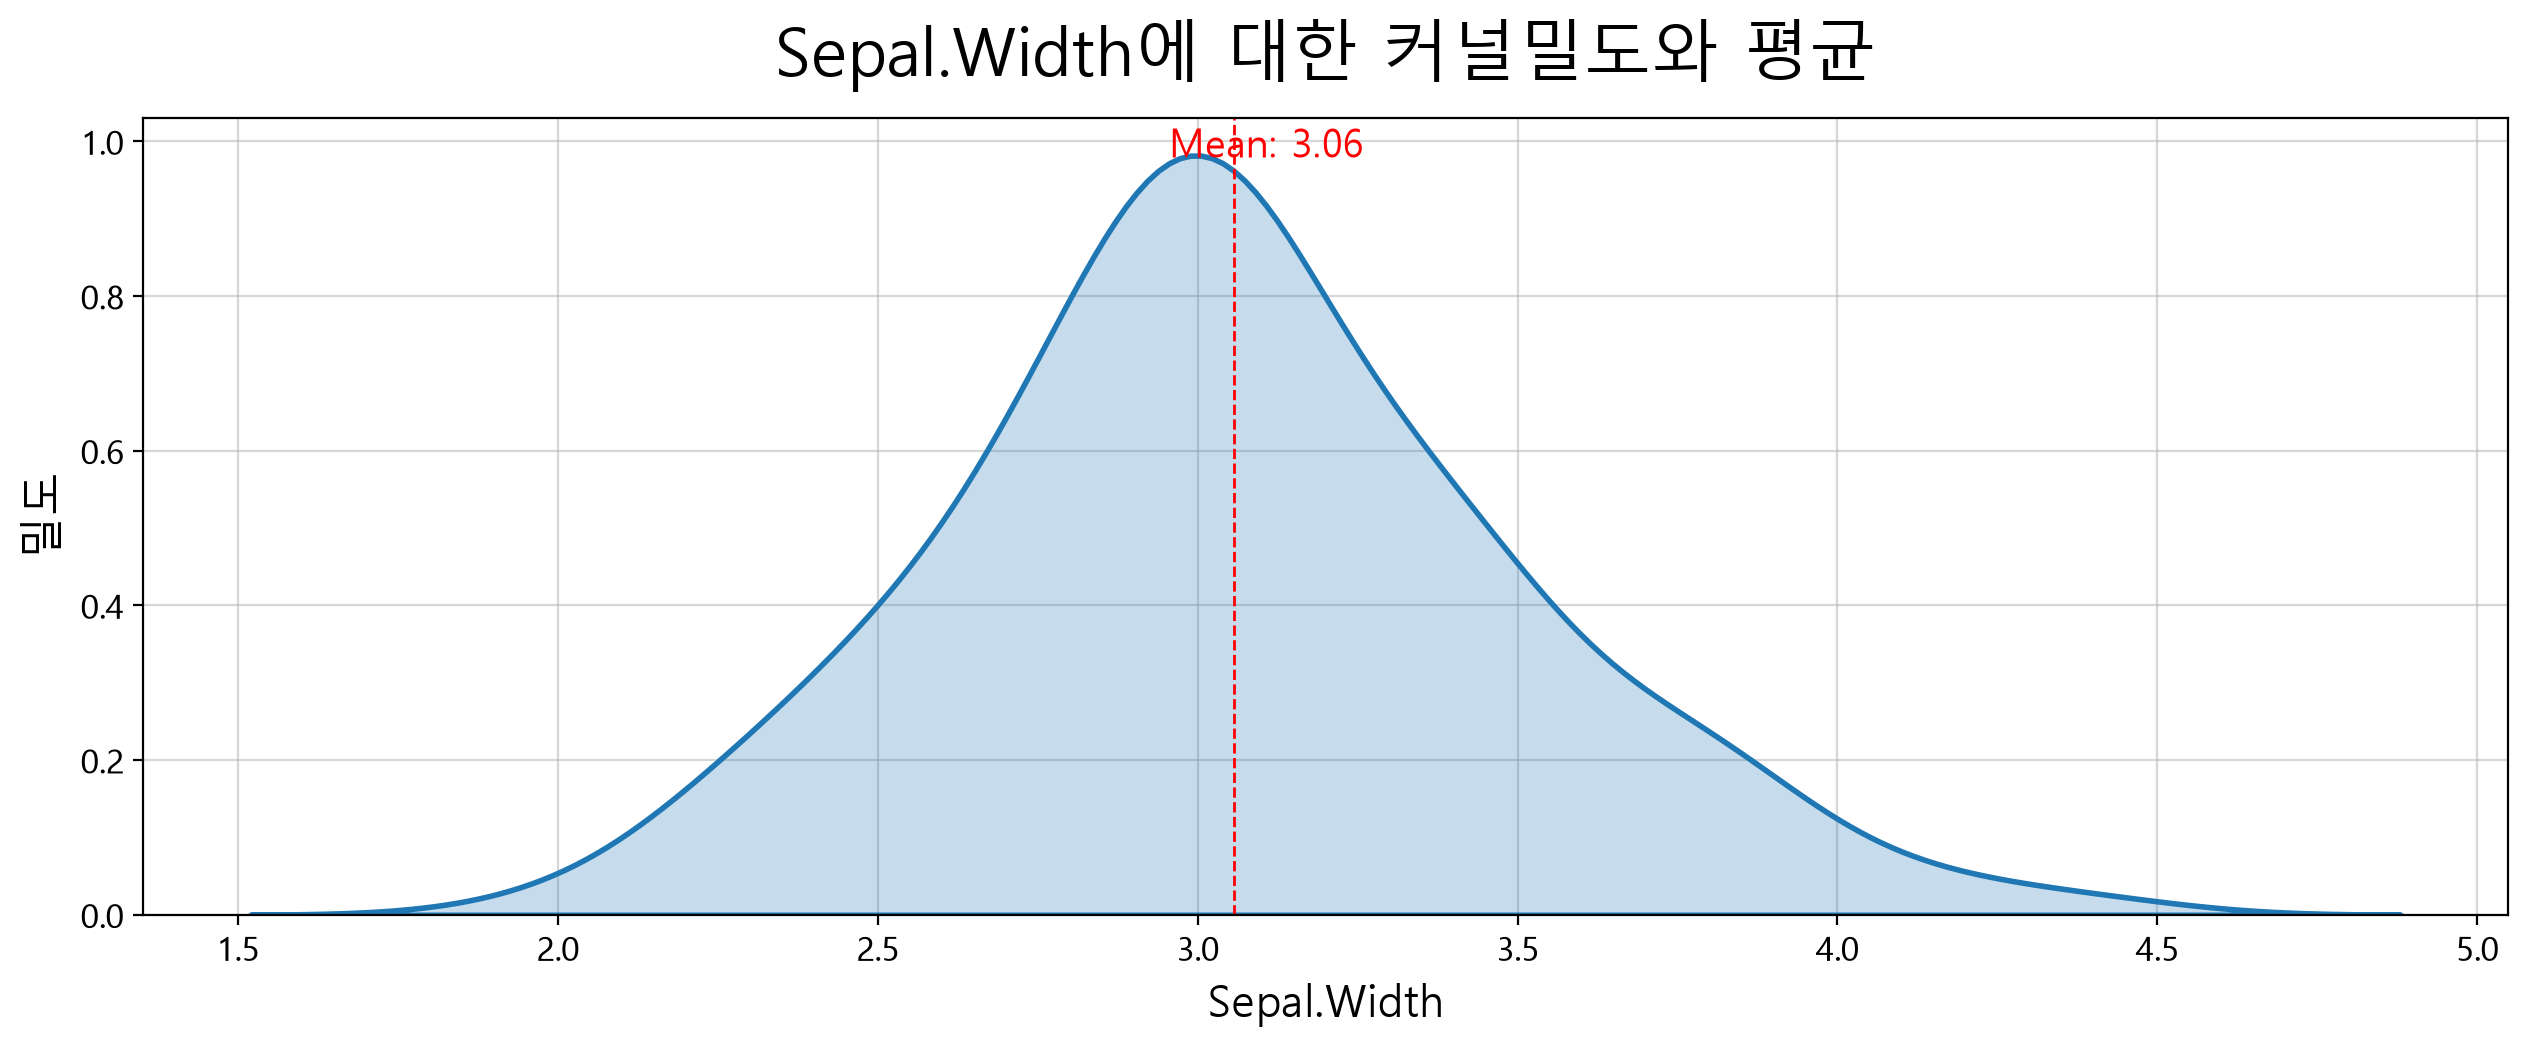

In [10]:
my_plot.kdeplot(title="Sepal.Width에 대한 커널밀도와 평균", 
                xlabel="Sepal.Width", ylabel="밀도",
                data=origin, x="Sepal.Width", meanline=True, fill=True)

### 3. 범주에 따른 구분 

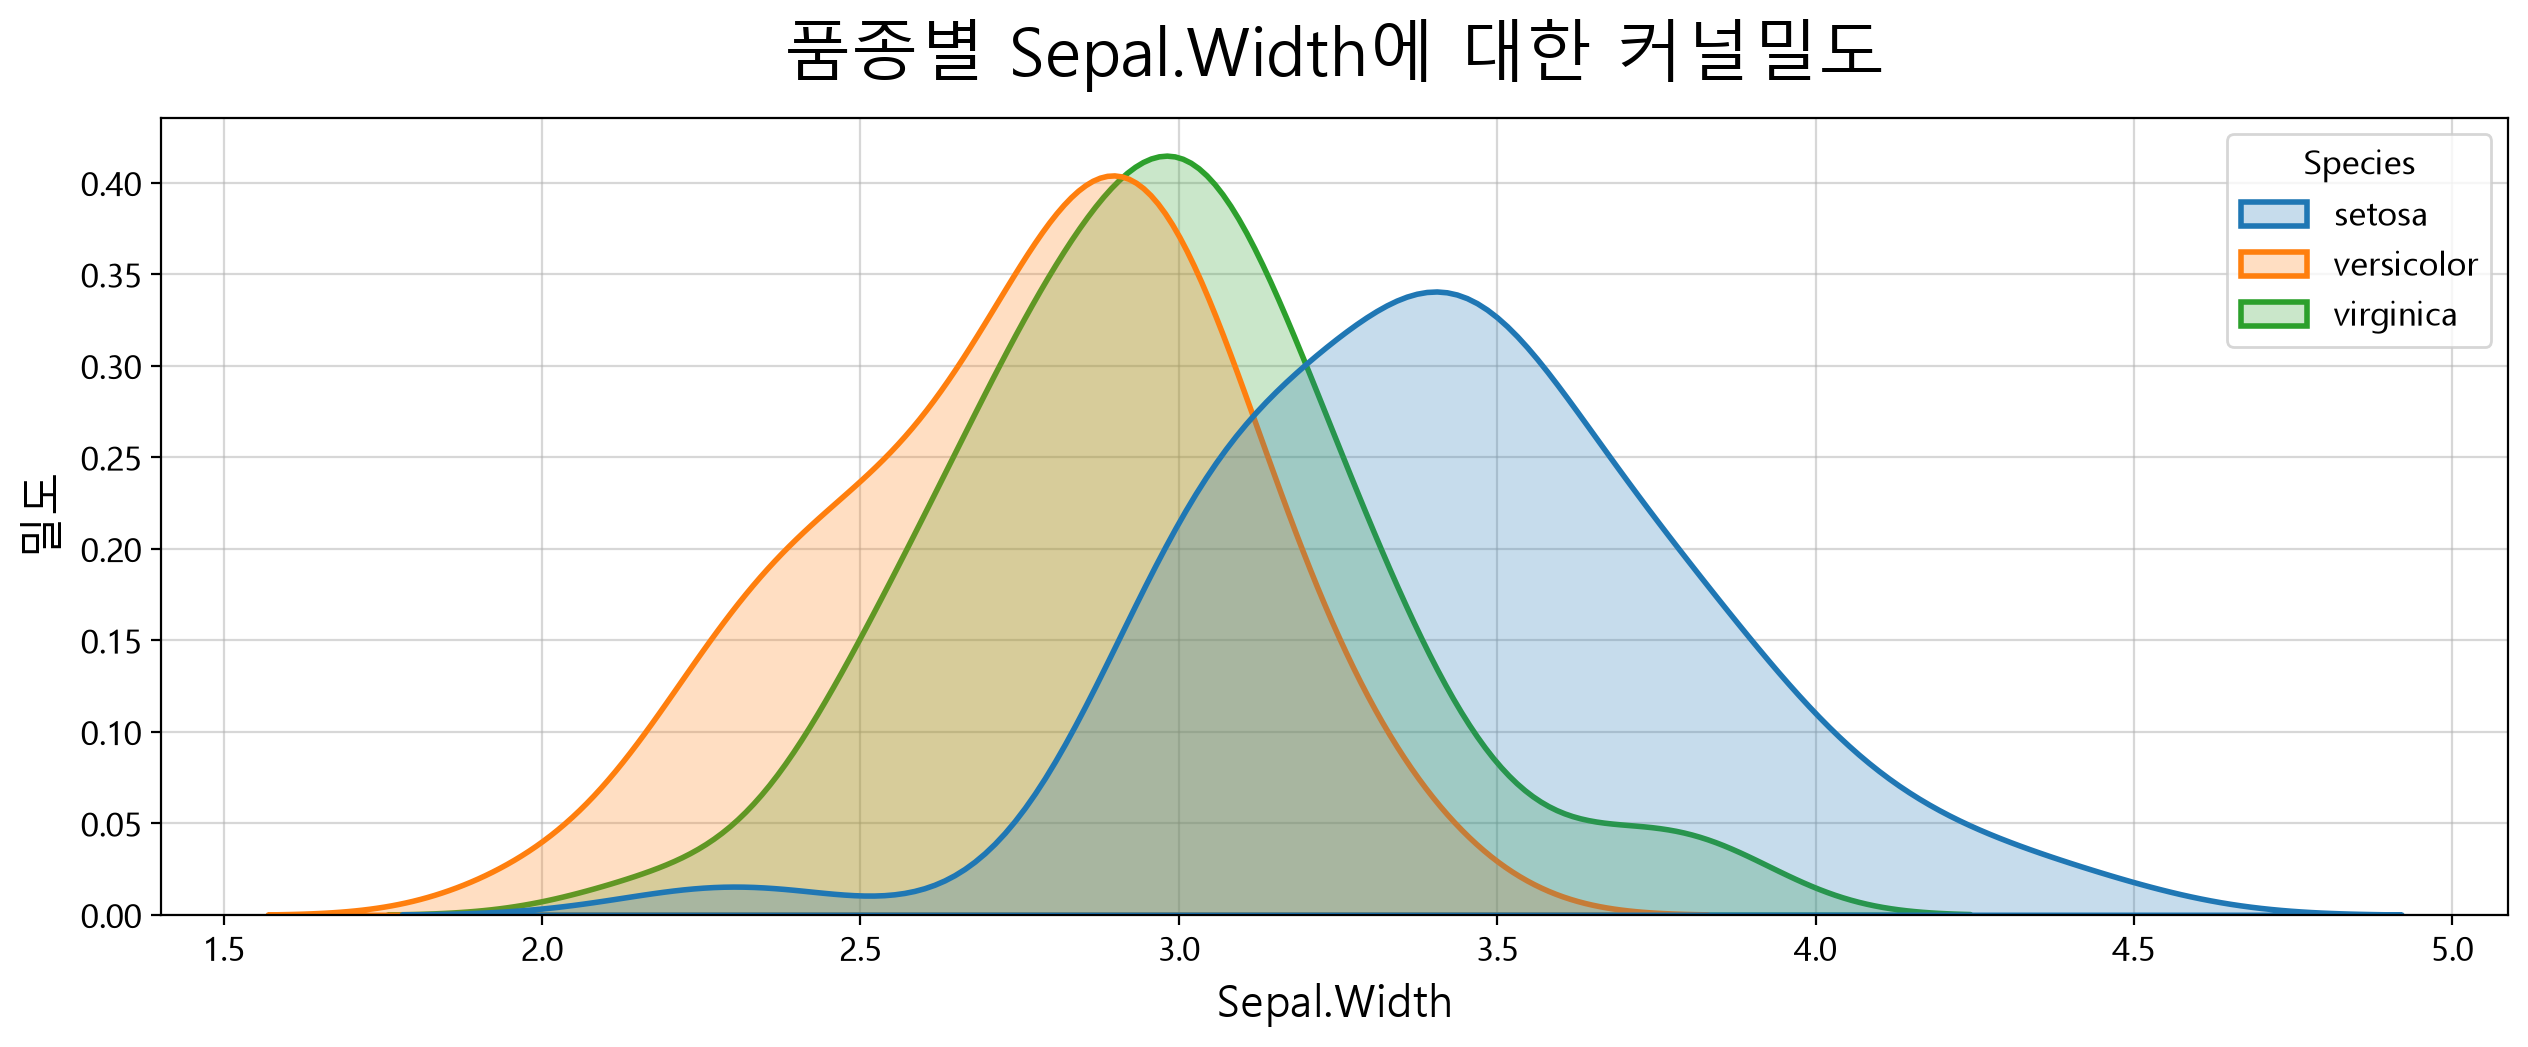

In [11]:
my_plot.kdeplot(title="품종별 Sepal.Width에 대한 커널밀도", 
                xlabel="Sepal.Width", ylabel="밀도", 
                data=origin, x="Sepal.Width", hue='Species', fill=True)

### 4. 범주에 따른 구분 + 평균선 

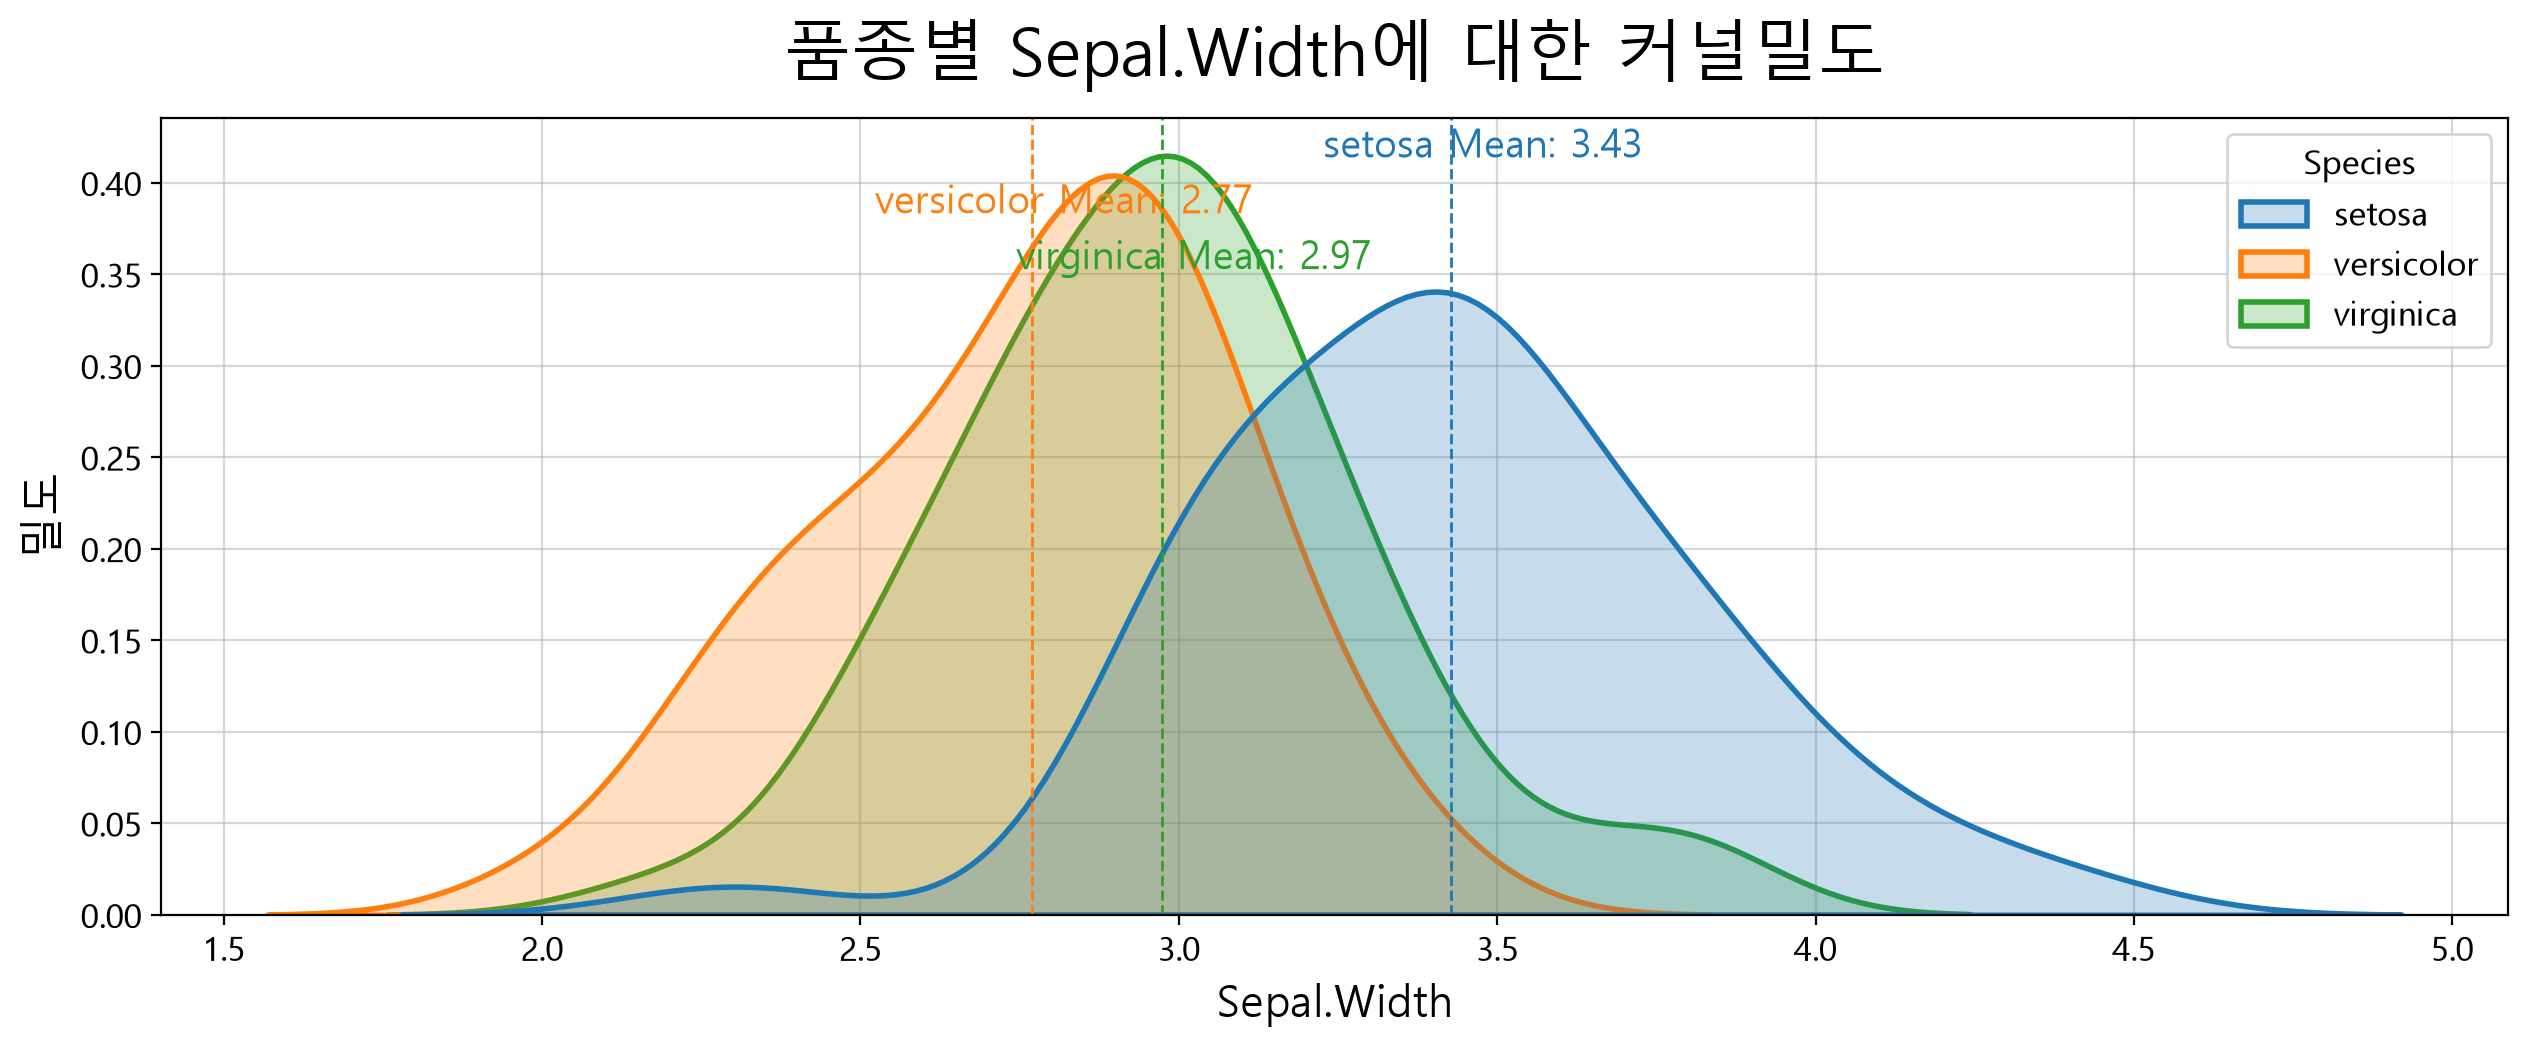

In [12]:
my_plot.kdeplot(title="품종별 Sepal.Width에 대한 커널밀도", 
                xlabel="Sepal.Width", ylabel="밀도", 
                data=origin, x="Sepal.Width", hue='Species', fill=True, 
                meanline=True)

## #01. 연습문제 

In [22]:
from jussam import load_data
from helpers import * 
import seaborn as sb

In [23]:
origin = load_data("analysis_grade") 
origin.head()

📚 통계학개론을 수강하는 두 학과(A, C)의 성적분포 데이터의 일부 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)


,학과,점수
0,C,54
1,A,52
2,A,37
3,C,41
4,A,67


In [25]:
df1 = origin[origin["학과"] == "A"]
df1.head()

,학과,점수
1,A,52
2,A,37
4,A,67
6,A,73
9,A,15


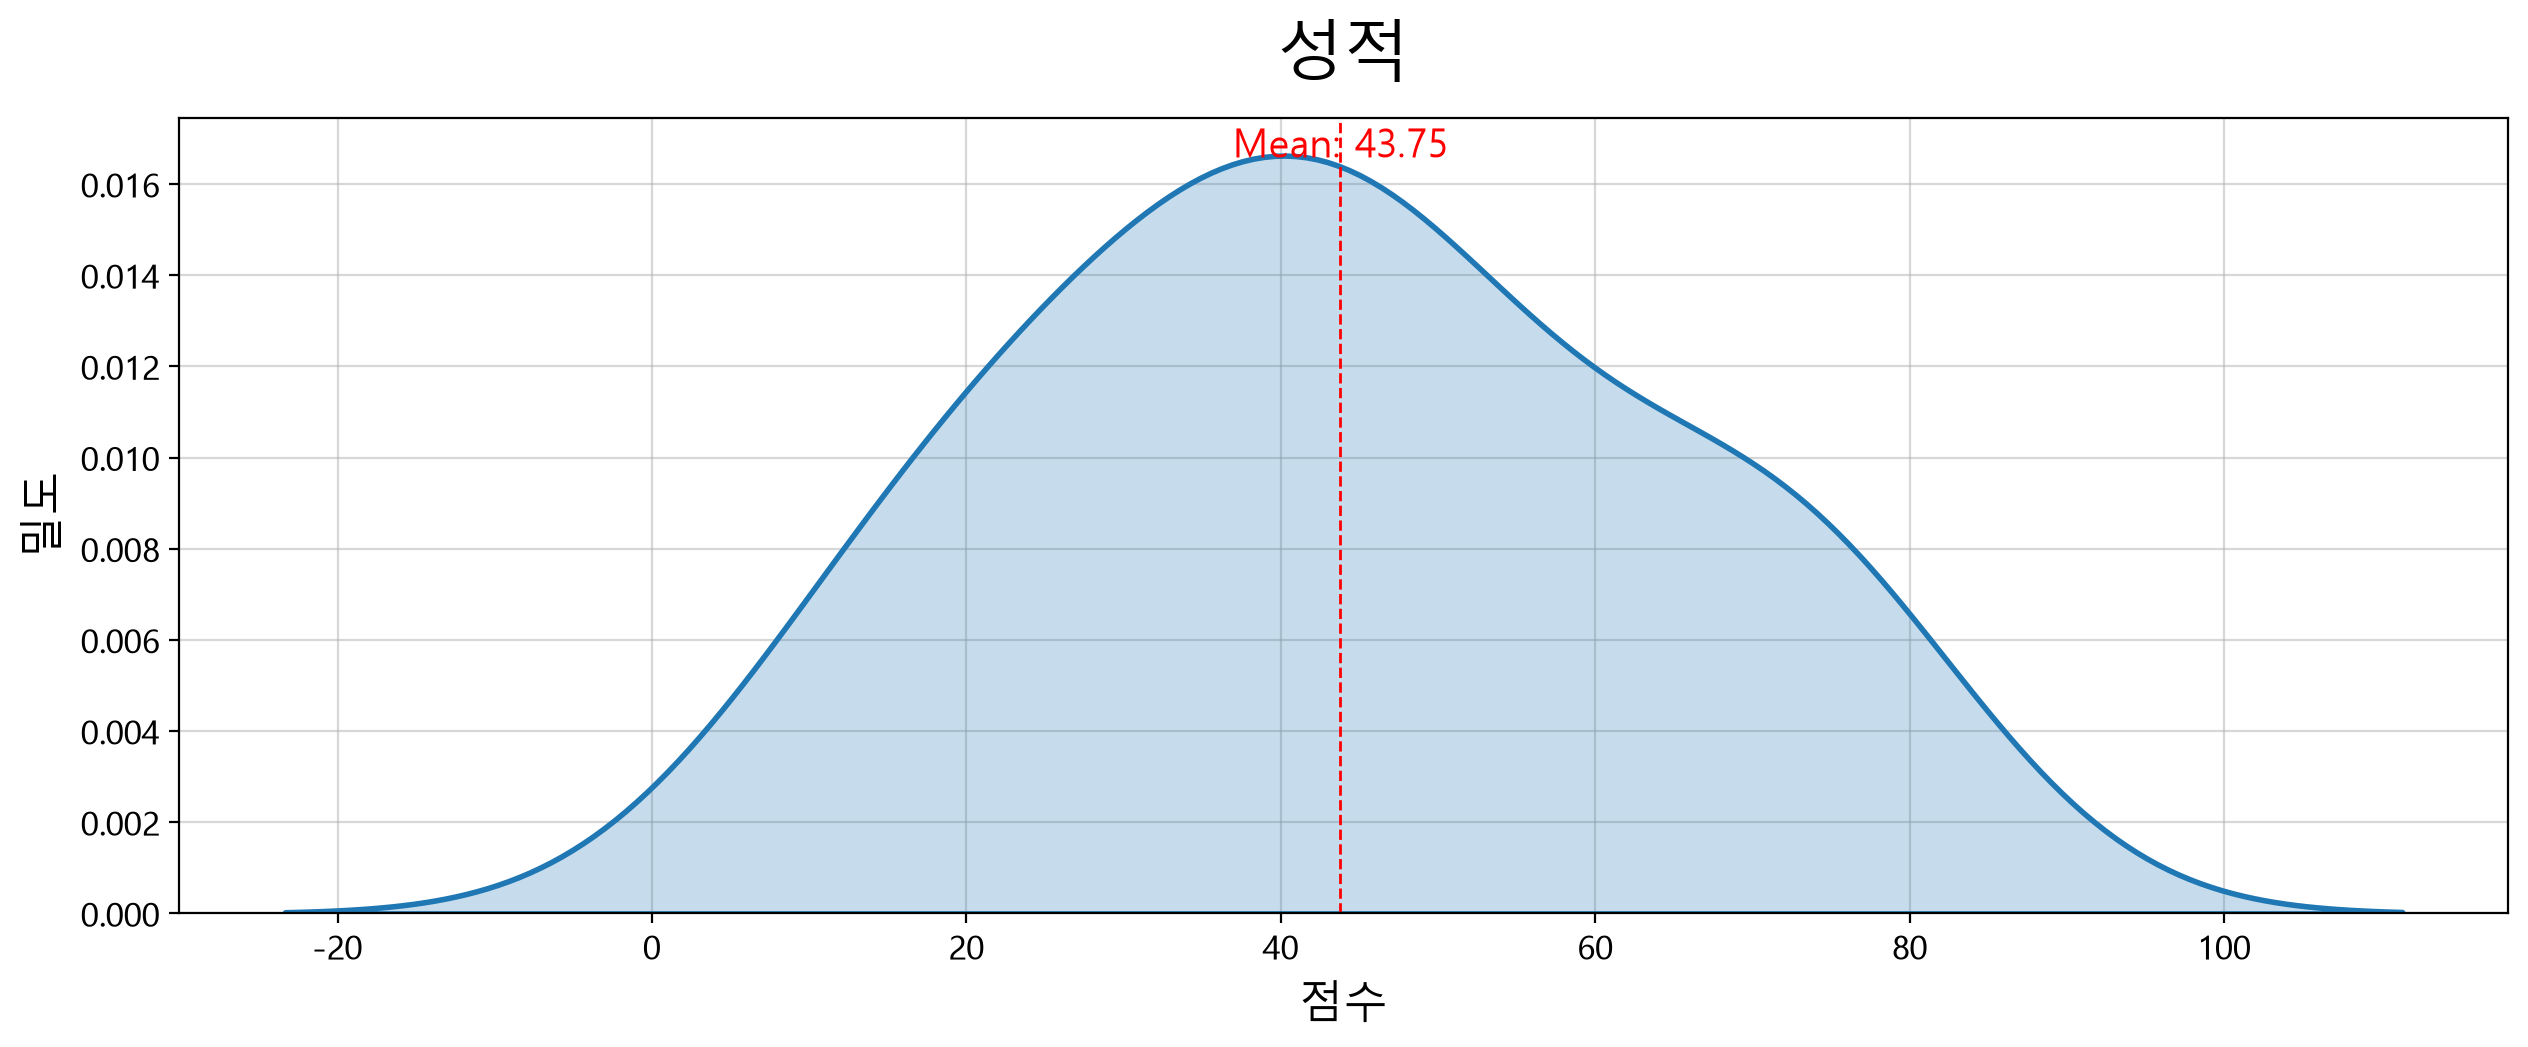

In [29]:
my_plot.kdeplot(title="성적", 
                xlabel="점수", ylabel="밀도", 
                data=df1, x="점수", meanline=True, fill=True)

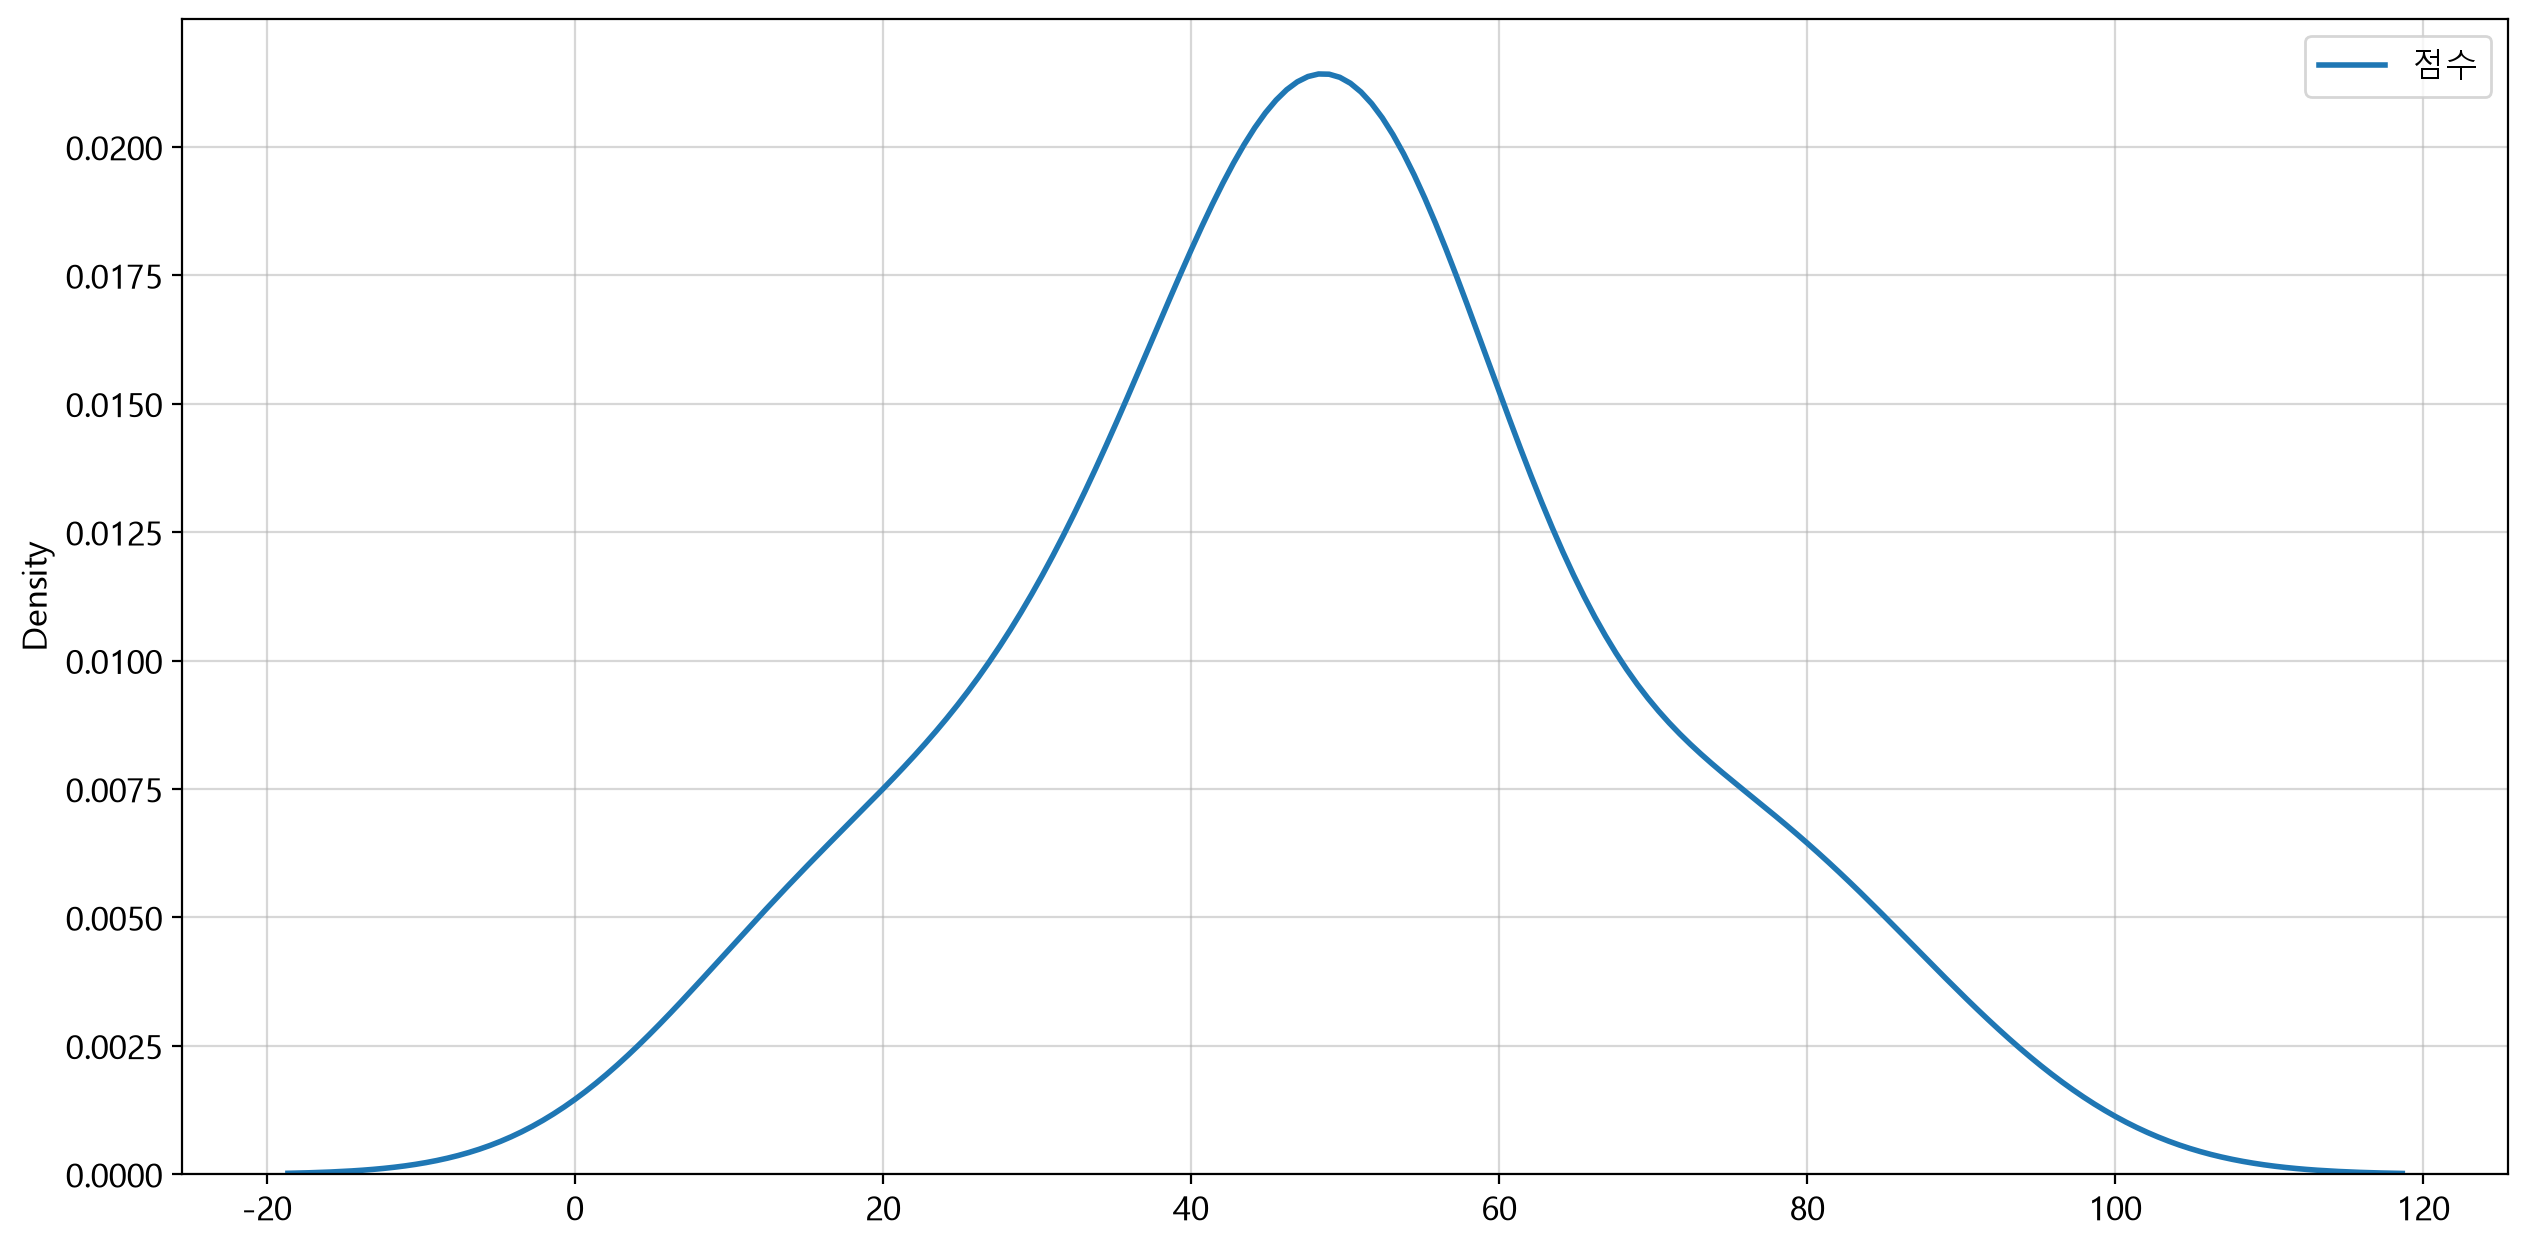

In [ ]:
fif, ax = my_plot.init()

sb.kdeplot(data=origin)

my_plot.show()

In [30]:
df2 = origin[origin["학과"] == 'C']
df2.head()

,학과,점수
0,C,54
3,C,41
5,C,43
7,C,51
8,C,55


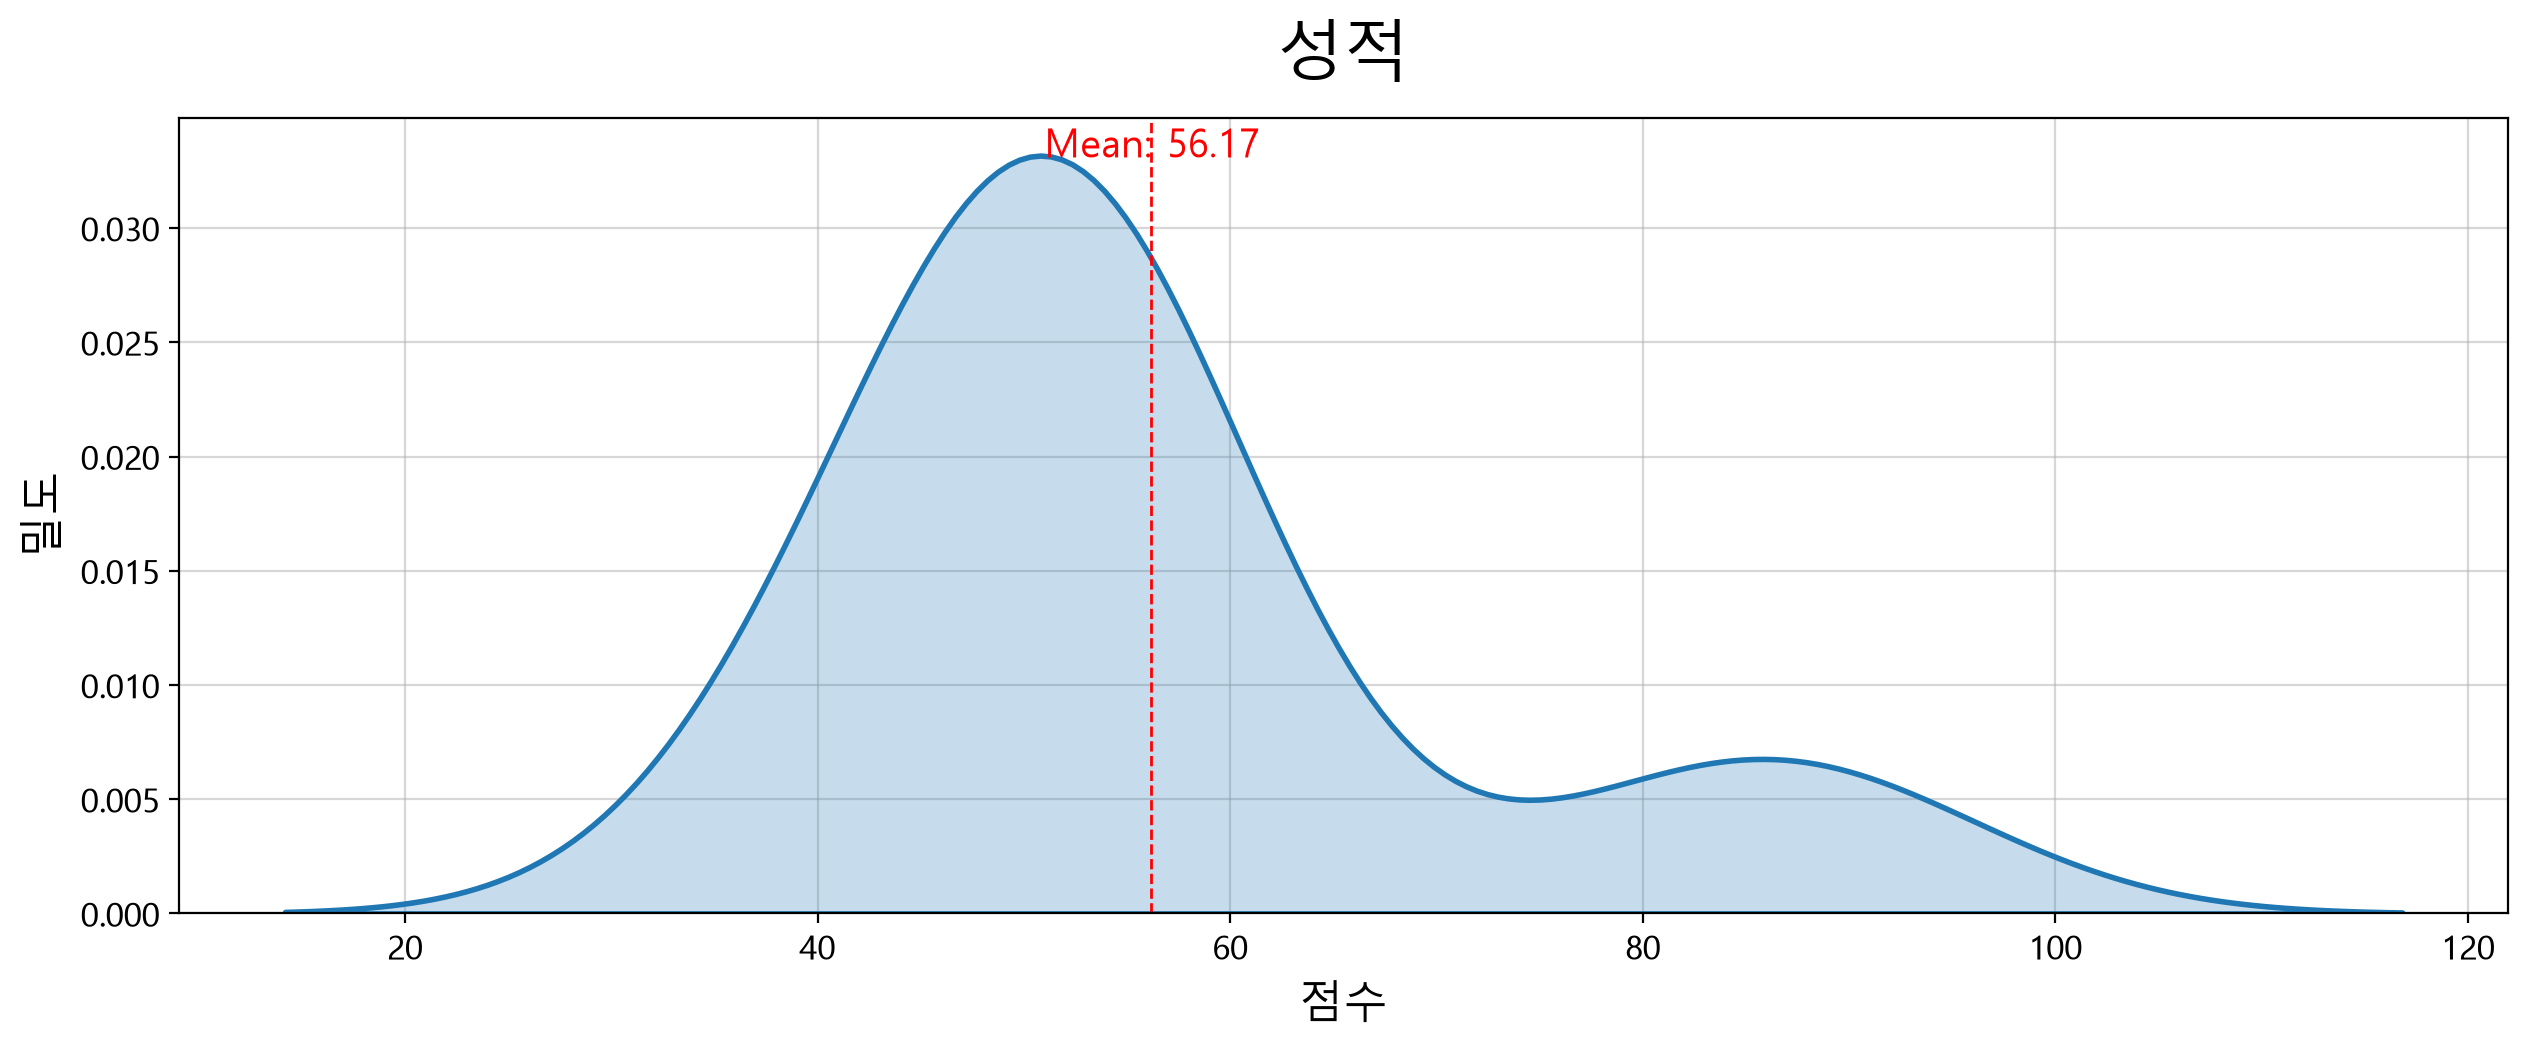

In [32]:
my_plot.kdeplot(title="성적", 
                xlabel="점수", ylabel="밀도", 
                data=df2, x="점수", meanline=True, fill=True)